# Exploratory Data Analysis (EDA)

## Home Credit Default Risk

Objective:
Understand customer characteristics, loan patterns, missing values, feature distributions, and relationships that influence loan default.

In [317]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [318]:
df = pd.read_csv("../data/raw/application_train.csv")

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [319]:
df.shape

df.info()

df.describe()

df.describe(include="object")

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


C:\Users\himan\AppData\Local\Temp\ipykernel_30984\1825841396.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,307511,307511,307511,307511,306219,307511,307511,307511,307511,211120,307511,307511,97216,153214,151170,161756
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,278232,202448,202924,213312,248526,158774,218391,196432,272868,55186,53901,67992,73830,150503,66040,159428


# 1. Target Variable Analysis

## Objective

The target variable (`TARGET`) indicates whether a customer experienced payment difficulties.

- TARGET = 0 → Loan Repaid
- TARGET = 1 → Loan Default

Understanding the class distribution is essential because an imbalanced dataset can significantly influence machine learning model performance and evaluation.

In [320]:
# Count the number of observations in each class
target_counts = df["TARGET"].value_counts()

# Display the counts
target_counts

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [321]:
# Calculate percentage distribution
target_percent = df["TARGET"].value_counts(normalize=True) * 100

target_percent.round(2)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

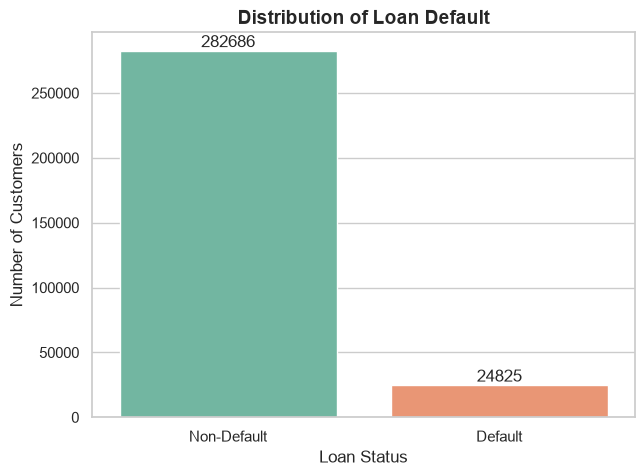

In [322]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="TARGET",
    hue="TARGET",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Loan Default", fontsize=14, fontweight="bold")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["Non-Default","Default"])

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

### Observation

The majority of customers successfully repaid their loans, while only a small proportion defaulted.

Approximately:

- 91.9% Non-default
- 8.1% Default

### Business Interpretation

The dataset is highly imbalanced.

If this imbalance is ignored, a machine learning model may simply predict every customer as a non-defaulter and still achieve high accuracy.

Therefore, evaluation metrics such as:

- Precision
- Recall
- F1-score
- ROC-AUC

will be more appropriate than accuracy alone.

### Credit Risk Insight

Banks typically experience far fewer defaults than successful repayments. Detecting the relatively small group of risky customers is the primary objective of a credit risk model.

This imbalance will later require techniques such as:

- Class weighting
- SMOTE (Synthetic Minority Over-sampling Technique)
- Threshold optimization

## Loan Default Proportion

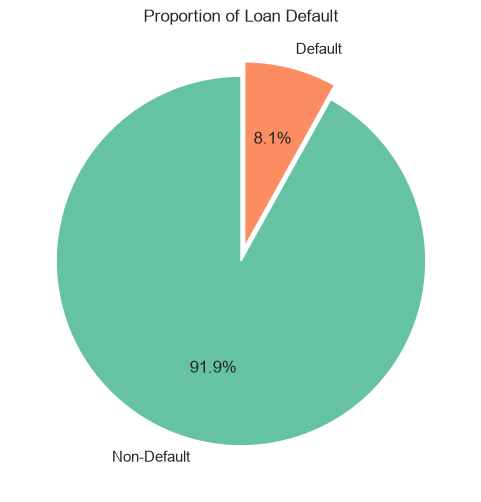

In [323]:
plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=["Non-Default", "Default"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66c2a5", "#fc8d62"],
    explode=[0, 0.08]
)

plt.title("Proportion of Loan Default")

plt.show()

### Observation

The pie chart shows that nearly all customers successfully repay their loans, while only a small proportion default.

### Business Interpretation

Although defaults account for only a small share of the portfolio, they represent a significant source of financial risk. Even a relatively small percentage of defaults can lead to substantial credit losses.

### Credit Risk Insight

This confirms that the dataset is imbalanced and highlights the importance of using appropriate evaluation metrics and imbalance-handling techniques during model development.

# 2. Applicant Demographic Analysis

## 2.1 Gender Analysis

### Objective

Customer demographics often influence borrowing behavior and repayment patterns.

In this section, we analyze the gender distribution of borrowers and compare the default rates between male and female applicants to determine whether gender provides useful information for credit risk assessment.

In [324]:
# Display the number of applicant by gender
gender_counts = df["CODE_GENDER"].value_counts()

gender_counts

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

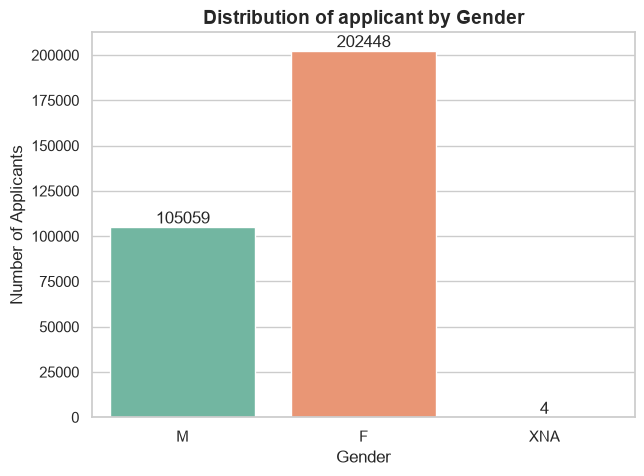

In [325]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="CODE_GENDER",
    hue="CODE_GENDER",
    palette="Set2",
    legend=False
)

plt.title("Distribution of applicant by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

The majority of loan applicants are female, while male applicants represent a smaller share of the portfolio. A very small number of observations are labeled as "XNA", indicating missing or undefined gender information.

### Business Interpretation

The bank's customer base consists predominantly of female borrowers.

However, the number of customers alone does not indicate whether one gender is riskier than the other. To evaluate credit risk accurately, we must compare the default rates for each gender rather than the total number of applicants.

### Credit Risk Insight

Gender may serve as a predictive feature if repayment behavior differs across groups. However, lending decisions should not rely solely on gender, as regulatory and ethical considerations require that credit assessments remain fair and primarily based on financial characteristics.

## 2.2 Default Rate by Gender

### Objective

While the customer distribution shows how many applicants belong to each gender, it does not indicate which group is more likely to default.

In this section, we calculate and compare the default rate across genders to evaluate whether gender is associated with repayment behavior.

In [326]:
# Calculate default rate by gender
gender_default_rate = (
    df.groupby("CODE_GENDER")["TARGET"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

gender_default_rate

CODE_GENDER
M      10.141920
F       6.999328
XNA     0.000000
Name: TARGET, dtype: float64

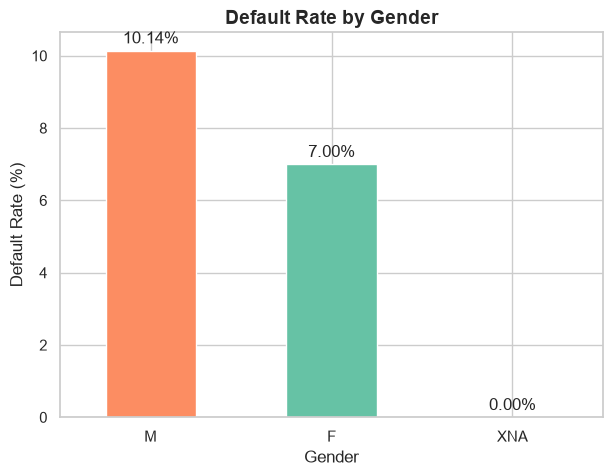

In [327]:
plt.figure(figsize=(7,5))

ax = gender_default_rate.plot(
    kind="bar",
    color=["#fc8d62", "#66c2a5", "#8da0cb"]
)

plt.title("Default Rate by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(gender_default_rate):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.show()

### Observation

Although female applicants represent the majority of customers, male applicants exhibit a higher default rate. The XNA category contains only a few observations and is therefore not meaningful for interpretation.

### Business Interpretation

The results suggest that repayment behavior differs across gender groups. However, gender alone should not be considered a causal factor for default. The observed differences may instead reflect variations in income, employment, family responsibilities, or other socioeconomic characteristics.

### Credit Risk Insight

Gender may contribute predictive information when combined with other variables in a machine learning model. Nevertheless, responsible lending practices require that credit decisions rely primarily on applicants' financial profiles rather than demographic characteristics alone.

## 2.3 Age Analysis

### Objective

Age is one of the most important demographic variables in credit risk analysis.

Borrowers at different stages of life often exhibit different financial behaviors, income stability, and repayment capacity.

In this section, we analyze the age distribution of applicants and investigate whether age influences loan default.

In [328]:
# Convert DAYS_BIRTH to age in years
df["AGE"] = (-df["DAYS_BIRTH"]) / 365

# Display summary statistics
df["AGE"].describe().round(2)

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\1719171899.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE"] = (-df["DAYS_BIRTH"]) / 365


count    307511.00
mean         43.94
std          11.96
min          20.52
25%          34.01
50%          43.15
75%          53.92
max          69.12
Name: AGE, dtype: float64

### 2.3.1 Age Distribution

#### Objective

Understanding the age distribution of loan applicants helps identify the primary customer segments served by the bank. It also provides insights into whether the applicant pool is concentrated within specific age groups and whether age may influence credit risk.

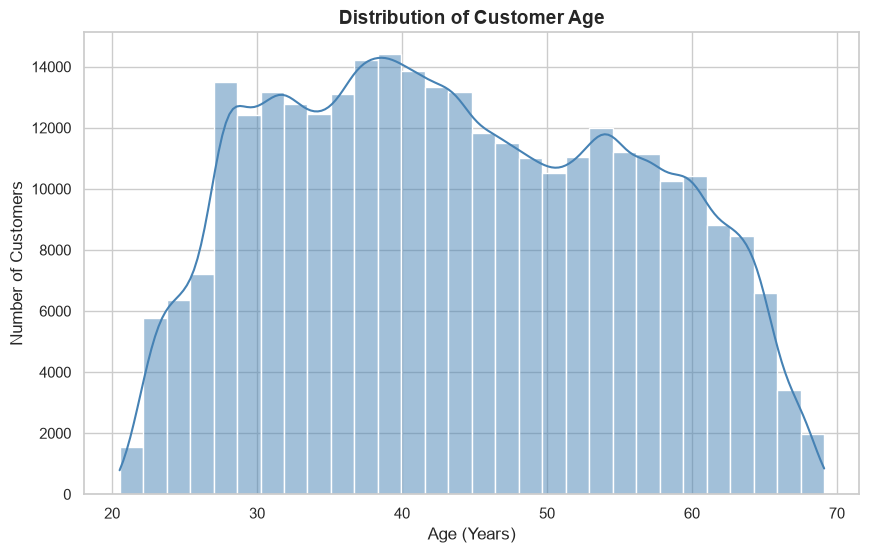

In [329]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AGE",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Age", fontsize=14, fontweight="bold")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The age distribution of applicants appears approximately bell-shaped, with most customers falling between 30 and 55 years of age.

Very young (below 25 years) and older (above 60 years) applicants represent a relatively small proportion of the customer base.

### Business Interpretation

The bank primarily serves working-age individuals who are more likely to have stable employment and regular income. This aligns with the typical target market for consumer credit products.

The lower representation of younger and older applicants may reflect lending policies, employment eligibility, or reduced borrowing demand within these age groups.

### Credit Risk Insight

Age is often associated with financial stability, employment experience, and repayment behavior. It is therefore an important feature for credit risk modeling and may contribute significantly to predicting loan default when combined with other financial variables.

### Key Takeaway

The Home Credit portfolio is primarily composed of middle-aged borrowers, indicating that the institution mainly serves economically active individuals. Age appears to be an important demographic feature for credit risk assessment. In the next analysis, we will examine whether default rates differ across age groups to determine how age influences repayment behavior.

## 2.3.2 Age Distribution using Boxplot

### Objective

A boxplot summarizes the distribution of customer ages by displaying the median, quartiles, spread, and potential outliers.

This visualization helps identify whether the bank's customer portfolio contains unusually young or old applicants that may require additional attention during credit risk assessment.

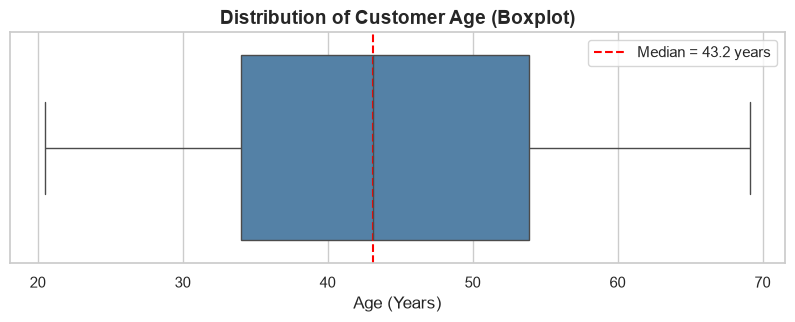

In [330]:
plt.figure(figsize=(10,3))

ax = sns.boxplot(
    data=df,
    x="AGE",
    color="steelblue"
)

median = df["AGE"].median()

plt.axvline(
    median,
    color="red",
    linestyle="--",
    label=f"Median = {median:.1f} years"
)

plt.title(
    "Distribution of Customer Age (Boxplot)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age (Years)")
plt.legend()

plt.show()

### Observation


The age distribution is well balanced, with the middle 50% of applicants falling approximately between 34 and 54 years of age. The median applicant age is approximately **43.2 years**.

No significant outliers are observed, indicating that the applicant population is concentrated within a typical working-age range.

### Business Interpretation

The bank's lending portfolio primarily consists of economically active individuals who are likely to have stable employment and regular income.

The absence of extreme age values suggests that the institution follows a relatively consistent customer acquisition strategy focused on its target lending population.

### Credit Risk Insight

Since the AGE variable does not contain significant outliers, it is unlikely to require outlier treatment during data preprocessing.

Age can therefore be incorporated directly into predictive models and may provide meaningful information about borrower repayment behaviour when combined with other financial variables.

### Key Takeaway

The customer portfolio exhibits a stable and well-defined age distribution with no abnormal observations. This indicates good data quality and suggests that age is a reliable demographic feature for credit risk modelling.

## 2.3.3 Default Rate by Age Group

### Objective

Customer age may influence repayment behaviour because borrowers at different stages of life often have different income stability, financial responsibilities, and borrowing needs.

In this section, we compare default rates across age groups to identify whether certain segments of the customer portfolio exhibit higher credit risk.

In [331]:
# Create age groups
age_bins = [20, 30, 40, 50, 60, 70]

age_labels = [
    "20-30",
    "30-40",
    "40-50",
    "50-60",
    "60-70"
]

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\2683157846.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_GROUP"] = pd.cut(


In [332]:
df["AGE_GROUP"].value_counts().sort_index()

AGE_GROUP
20-30    45021
30-40    82308
40-50    76541
50-60    68062
60-70    35579
Name: count, dtype: int64

In [333]:
age_default_rate = (
    df.groupby("AGE_GROUP")["TARGET"]
      .mean()
      .mul(100)
)

age_default_rate

AGE_GROUP
20-30    11.456876
30-40     9.583516
40-50     7.650802
50-60     6.129705
60-70     4.921442
Name: TARGET, dtype: float64

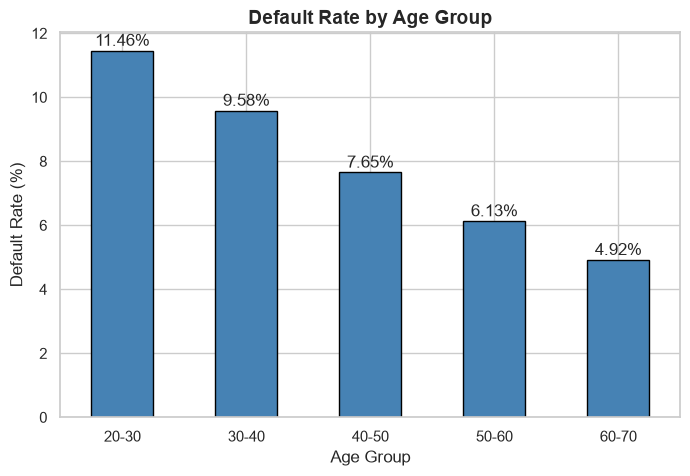

In [334]:
plt.figure(figsize=(8,5))

ax = age_default_rate.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title(
    "Default Rate by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

# Add labels
for i, value in enumerate(age_default_rate):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

### Observation

The default rate shows a clear downward trend as customer age increases.

Applicants aged **20–30 years** have the highest default rate (**11.46%**), while borrowers aged **60–70 years** have the lowest default rate (**4.92%**).

This indicates a strong inverse relationship between age and loan default within the Home Credit portfolio.

### Business Interpretation

Younger borrowers generally have less stable employment, shorter credit histories, and lower accumulated wealth, which may increase their likelihood of experiencing repayment difficulties.

In contrast, older borrowers tend to have greater financial stability, more work experience, and stronger repayment capacity, contributing to lower default rates.

### Credit Risk Insight

The consistent decline in default rates across increasing age groups suggests that age is an informative predictor of credit risk.

This variable is likely to contribute meaningful predictive power when combined with financial variables such as income, employment status, and credit amount in machine learning models.

### Key Takeaway

Age exhibits a strong inverse relationship with loan default in the Home Credit dataset. Younger applicants represent the highest-risk customer segment, while default risk decreases progressively with age. This finding highlights the importance of incorporating age into credit risk assessment and predictive modeling.



## 2.4 Family Status Analysis

### Objective

Family status reflects an applicant's household structure and financial responsibilities. Different marital groups may exhibit varying repayment behavior due to differences in income stability, financial obligations, and household support.



This section analyzes the distribution of family status and investigates whether default rates differ across marital groups.


In [335]:

df["NAME_FAMILY_STATUS"].value_counts()


NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

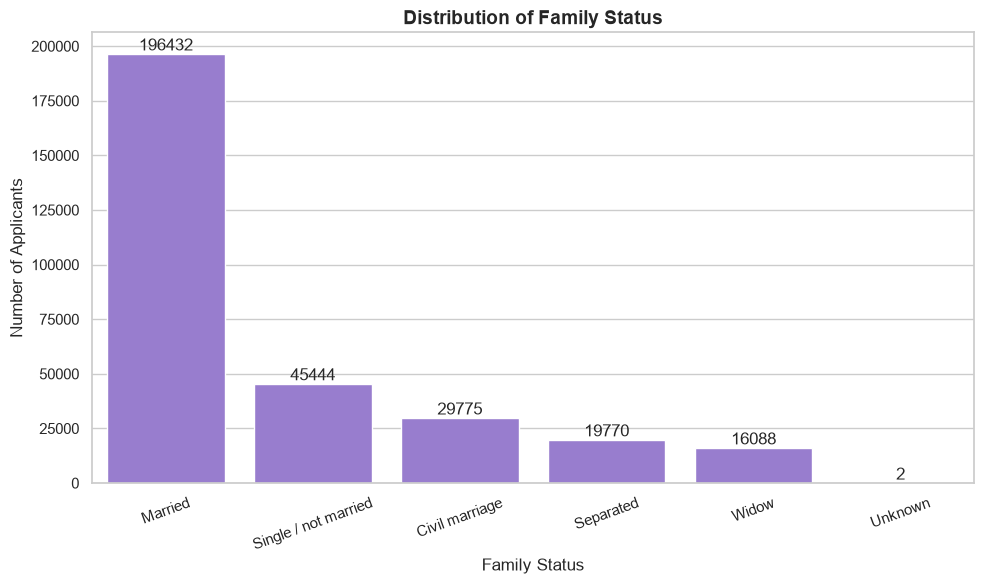

In [336]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="NAME_FAMILY_STATUS",
    order=df["NAME_FAMILY_STATUS"].value_counts().index,
    color="mediumpurple"
)

plt.title(
    "Distribution of Family Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Family Status")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()


### Observation

The applicant portfolio is dominated by married individuals, accounting for approximately two-thirds of all loan applicants.

Single applicants form the second-largest group, followed by borrowers in civil marriages, separated individuals, and widows. Only two applicants belong to the "Unknown" category, making it statistically insignificant for analysis.


### Business Interpretation

The predominance of married applicants suggests that the bank primarily serves households with established family structures.

Marital status may influence repayment behavior through differences in household income, financial responsibilities, and access to family support during periods of financial stress.


### Credit Risk Insight

Although family status alone does not determine creditworthiness, it provides useful demographic information that may improve risk segmentation when combined with variables such as income, employment stability, number of dependents, and credit history.


### Key Takeaway

Most borrowers in the Home Credit portfolio are married, indicating that family status is an important demographic characteristic. The actual predictive value of this variable will be determined by comparing default rates across different family status groups.


# 2.4.1 Do married people default less than single people?


In [337]:
order = [
    "Married",
    "Single / not married",
    "Civil marriage",
    "Separated",
    "Widow",
    "Unknown"
]

family_default_rate = (
    df.groupby("NAME_FAMILY_STATUS", observed=False)["TARGET"]
      .mean()
      .mul(100)
      .round(2)
      .reindex(order)
)
family_default_rate

NAME_FAMILY_STATUS
Married                 7.56
Single / not married    9.81
Civil marriage          9.94
Separated               8.19
Widow                   5.82
Unknown                 0.00
Name: TARGET, dtype: float64

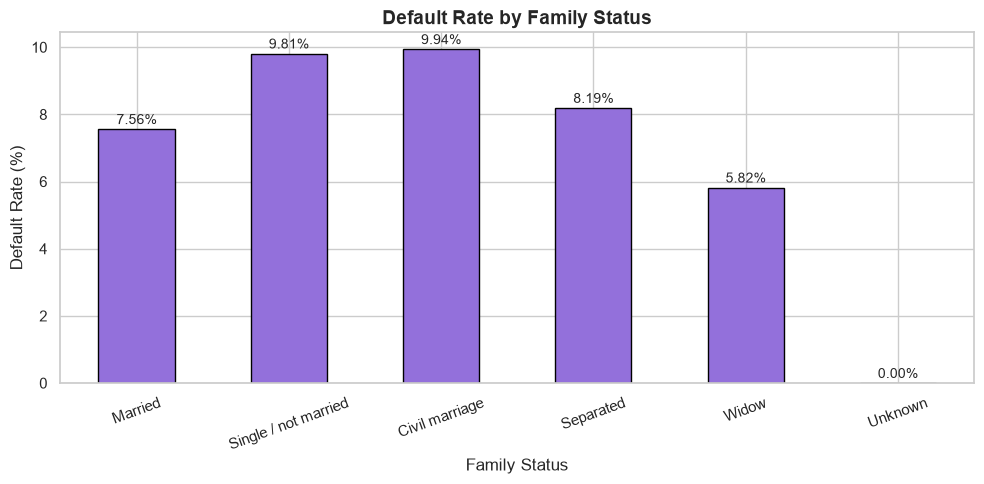

In [338]:
plt.figure(figsize=(10,5))

ax = family_default_rate.plot(
    kind="bar",
    color="mediumpurple",
    edgecolor="black"
)

plt.title(
    "Default Rate by Family Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Family Status")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=20)

for i, value in enumerate(family_default_rate):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


### Observation

The default rate varies across different family status categories.

Borrowers in civil marriages exhibit the highest default rate (9.94%), closely followed by single applicants (9.81%).

Married applicants have a substantially lower default rate (7.56%), while widowed applicants show the lowest observed default rate (5.82%). The "Unknown" category contains only two observations and is therefore not considered meaningful.


### Business Interpretation

Applicants with stable family structures generally demonstrate lower default rates than applicants who are unmarried or living in civil marriages.

Married households may benefit from dual-income support, greater financial stability, and shared repayment responsibilities, reducing the probability of loan default.

Conversely, single borrowers and applicants in civil marriages may experience higher financial volatility, contributing to elevated credit risk.


### Credit Risk Insight

Family status appears to be an informative demographic predictor of credit risk.

Although marital status should not be used independently for lending decisions, it can improve model performance when combined with employment history, income level, number of dependents, existing liabilities, and credit bureau information.


### Key Takeaway

Married applicants exhibit lower default rates than single applicants in the Home Credit portfolio, suggesting that household stability is associated with stronger repayment behavior.

## 2.5 Number of Children Analysis

### Objective

Analyze the distribution of the number of children among loan applicants and examine whether applicants with more children exhibit different default rates. This analysis helps determine whether family responsibilities contribute to credit risk.


### Business Context

The number of dependent children can influence an applicant's financial obligations. Households with more children often have higher living expenses, which may reduce disposable income available for loan repayment.

Although the number of children alone is not sufficient to determine creditworthiness, it may provide additional insights when combined with other variables such as income, employment stability, and existing debt.


In [339]:
df['CNT_CHILDREN'].describe()


count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

### Observation

The `CNT_CHILDREN` variable contains no missing values, indicating complete information for all applicants. The median value of 0 shows that at least half of the applicants do not have children, while 75% have one or fewer children. The maximum value of 19 suggests the presence of a few applicants with unusually large families, which should be examined further during the distribution and outlier analysis.


In [340]:
df['CNT_CHILDREN'].skew()


np.float64(1.974604469694792)

### Observation

The `CNT_CHILDREN` variable is positively skewed (skewness ≈ 1.97), indicating that most applicants have few or no children, while a small proportion report larger families. The presence of applicants with many children creates a long right tail in the distribution.


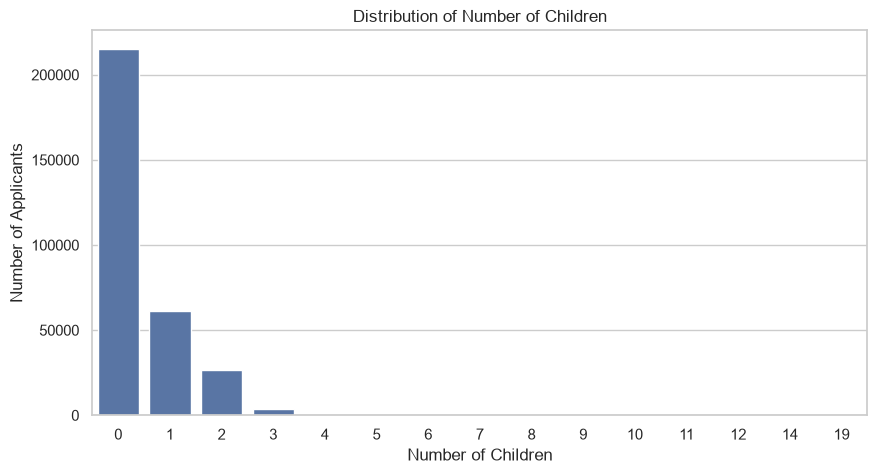

In [341]:

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='CNT_CHILDREN'
)

plt.title("Distribution of Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Number of Applicants")

plt.show()


### Observation

The count plot shows that the majority of applicants do not have children, with the highest frequency occurring at zero children. The number of applicants declines steadily as the number of children increases, indicating that large families are relatively uncommon. This pattern is consistent with the positive skewness observed earlier.


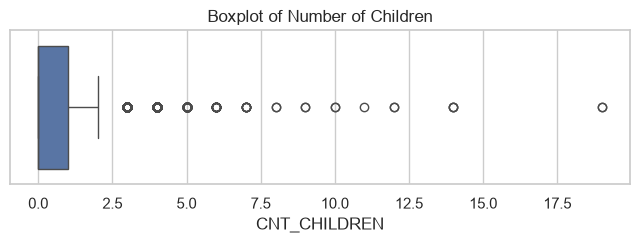

In [342]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df['CNT_CHILDREN']
)

plt.title("Boxplot of Number of Children")

plt.show()


### Observation

The boxplot indicates that applicants with more than two children appear as statistical outliers based on the IQR method. However, these values represent plausible family sizes rather than obvious data errors. Therefore, they should be retained for further analysis while acknowledging that large families are relatively uncommon in the dataset.


In [343]:
df['CNT_CHILDREN'].value_counts().sort_index()


CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

In [344]:
df['CHILDREN_GROUP'] = pd.cut(
    df['CNT_CHILDREN'],
    bins=[-1, 0, 2, 20],
    labels=[
        'No Children',
        '1-2 Children',
        '3+ Children'
    ]
)


C:\Users\himan\AppData\Local\Temp\ipykernel_30984\3148926055.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CHILDREN_GROUP'] = pd.cut(


In [345]:
df['CHILDREN_GROUP'].value_counts()


CHILDREN_GROUP
No Children     215371
1-2 Children     87868
3+ Children       4272
Name: count, dtype: int64

In [346]:
children_default = (
    df.groupby('CHILDREN_GROUP')['TARGET']
      .mean()
      .reset_index()
)

children_default


,CHILDREN_GROUP,TARGET
0,No Children,0.077118
1,1-2 Children,0.088622
2,3+ Children,0.100421


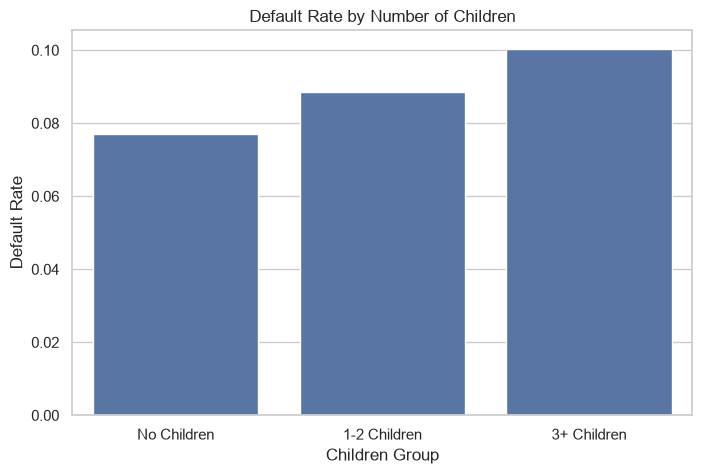

In [347]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=children_default,
    x='CHILDREN_GROUP',
    y='TARGET'
)

plt.title("Default Rate by Number of Children")
plt.xlabel("Children Group")
plt.ylabel("Default Rate")

plt.show()


### Business Interpretation

The analysis indicates that applicants with a greater number of children tend to have higher default rates. Larger families often face increased household expenses related to education, healthcare, and daily living, which can reduce the disposable income available for loan repayments.

However, family size should not be evaluated in isolation. Lenders should consider this variable alongside income, employment stability, and existing debt obligations when assessing an applicant's overall credit risk.


### Credit Risk Insight

The default rate increases from approximately 7.7% for applicants with no children to around 10.0% for applicants with three or more children. This suggests that greater family responsibilities may contribute to higher credit risk. Nevertheless, the number of children should be considered a supporting predictor rather than a standalone indicator of default.


### Key Takeaway

Most applicants do not have children, while applicants with larger families represent only a small proportion of the dataset. The analysis shows a gradual increase in default rates as the number of children increases, indicating that family responsibilities may influence repayment capacity. However, this variable should always be interpreted together with income, employment stability, and other financial characteristics when assessing credit risk.

## 2.6 Family Members Analysis



### Objective

Analyze the distribution of family size among loan applicants and evaluate whether larger households are associated with higher default rates.


### Business Context

The total number of family members reflects an applicant's household size and financial responsibilities. Larger households often require greater expenditure on housing, food, healthcare, and education, which may reduce the disposable income available for loan repayments.

Analyzing family size helps determine whether household composition influences credit risk and provides additional insight when combined with income, employment, and other financial variables.


In [348]:
df['CNT_FAM_MEMBERS'].describe()


count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

### Observation

The `CNT_FAM_MEMBERS` variable contains information for 307,509 applicants, with only two missing values. The median household size is two members, while 75% of applicants belong to households with three or fewer family members. The maximum household size of 20 indicates the presence of a few unusually large families that will be examined further during the distribution and outlier analysis.


In [349]:
df['CNT_FAM_MEMBERS'].skew()


np.float64(0.987542813719218)

### Observation

The `CNT_FAM_MEMBERS` variable is moderately positively skewed (skewness ≈ 0.99), indicating that most applicants belong to relatively small households, while only a small proportion belong to larger families. The positive skewness reflects the presence of a few applicants with unusually large household sizes.


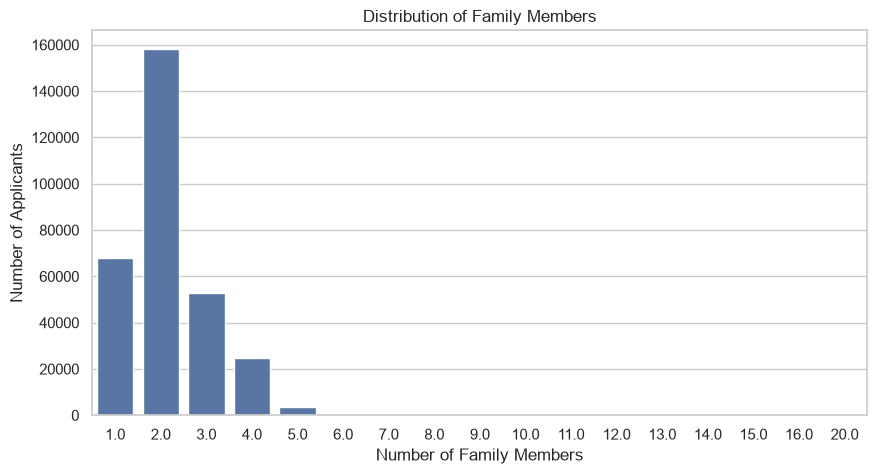

In [350]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='CNT_FAM_MEMBERS'
)

plt.title("Distribution of Family Members")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Applicants")

plt.show()


### Observation

The count plot shows that two-member households are the most common among loan applicants, followed by one- and three-member households. The number of applicants decreases steadily as household size increases, indicating that large families are relatively uncommon. This distribution is consistent with the moderate positive skewness observed earlier.


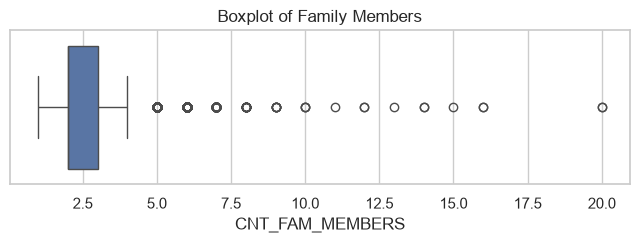

In [351]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df['CNT_FAM_MEMBERS']
)

plt.title("Boxplot of Family Members")

plt.show()


### Observation

The boxplot identifies applicants with more than four family members as statistical outliers based on the IQR method. These observations represent relatively uncommon household sizes rather than obvious data errors. Therefore, they are retained for further analysis while acknowledging that large households are rare within the dataset.


In [352]:
df['CNT_FAM_MEMBERS'].value_counts().sort_index()


CNT_FAM_MEMBERS
1.0      67847
2.0     158357
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
11.0         1
12.0         2
13.0         1
14.0         2
15.0         1
16.0         2
20.0         2
Name: count, dtype: int64

In [353]:
df['FAMILY_SIZE_GROUP'] = pd.cut(
    df['CNT_FAM_MEMBERS'],
    bins=[0, 2, 4, 20],
    labels=[
        'Small Household (1-2)',
        'Medium Household (3-4)',
        'Large Household (5+)'
    ]
)


C:\Users\himan\AppData\Local\Temp\ipykernel_30984\1385174678.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['FAMILY_SIZE_GROUP'] = pd.cut(


In [354]:
df['FAMILY_SIZE_GROUP'].value_counts()


FAMILY_SIZE_GROUP
Small Household (1-2)     226204
Medium Household (3-4)     77298
Large Household (5+)        4007
Name: count, dtype: int64

In [355]:
family_default = (
    df.groupby('FAMILY_SIZE_GROUP')['TARGET']
      .mean()
      .reset_index()
)
family_default



,FAMILY_SIZE_GROUP,TARGET
0,Small Household (1-2),0.078177
1,Medium Household (3-4),0.087247
2,Large Household (5+),0.099077


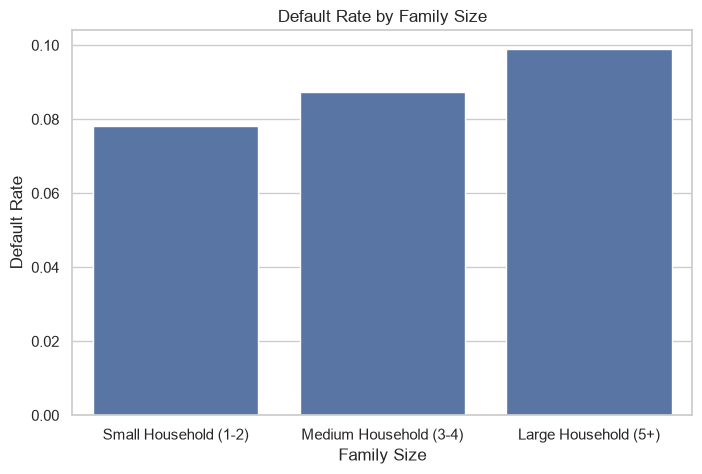

In [356]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=family_default,
    x='FAMILY_SIZE_GROUP',
    y='TARGET'
)

plt.title("Default Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Default Rate")

plt.show()


### Observation

The default rate increases consistently with household size. Applicants from small households (1–2 members) have the lowest default rate, while applicants from large households (5 or more members) exhibit the highest default rate. This suggests that increasing household responsibilities may be associated with higher credit risk.


### Business Interpretation

Larger households generally face higher living expenses, including housing, food, healthcare, and education costs. These additional financial obligations may reduce the disposable income available for loan repayments, contributing to a higher probability of default.

However, household size alone does not determine creditworthiness. It should be evaluated alongside income, employment stability, debt obligations, and other financial characteristics to obtain a comprehensive assessment of an applicant's repayment capacity.


### Credit Risk Insight

The analysis indicates a gradual increase in default rates as household size increases, from approximately 7.8% for small households to nearly 10.0% for large households. This suggests that family size provides useful supplementary information for credit risk assessment. Nevertheless, it should be considered as one component of a broader risk evaluation framework rather than a standalone predictor.


### Key Takeaway

Most applicants belong to small households, while large households represent only a small proportion of the dataset. The observed increase in default rates across larger household groups suggests that household size may influence repayment capacity by increasing financial responsibilities. When combined with income and employment information, family size can provide valuable insights for credit risk assessment.

# 3. Financial Profile Analysis

## 3.1 Income Analysis

### Objective

Applicant income is one of the primary indicators of repayment capacity and plays a crucial role in credit risk assessment.

In this section, we analyze the distribution of applicant income, identify potential outliers, and evaluate whether the income data requires preprocessing before model development.

In [357]:
# Summary statistics for applicant income
df["AMT_INCOME_TOTAL"].describe().round(2)

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [358]:
print("Skewness:", round(df["AMT_INCOME_TOTAL"].skew(), 2))

Skewness: 391.56


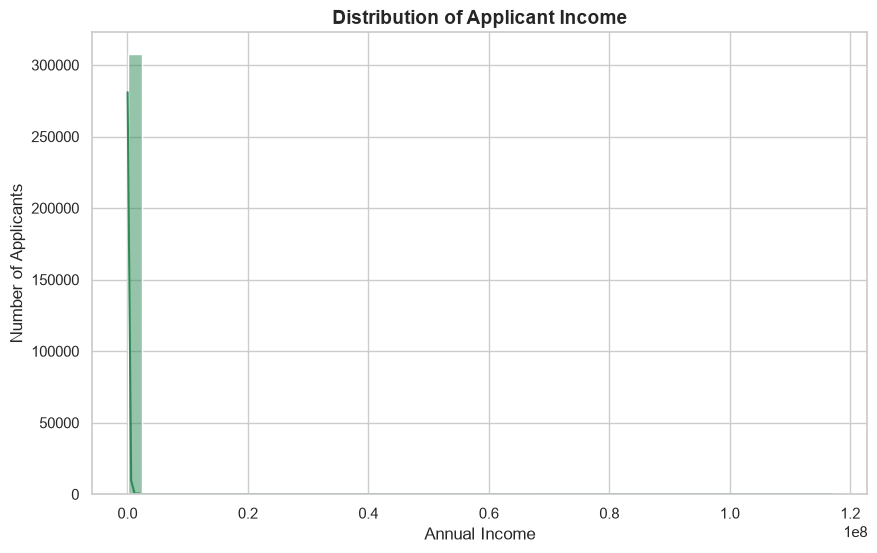

In [359]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=50,
    kde=True,
    color="seagreen"
)

plt.title(
    "Distribution of Applicant Income",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.show()

# 3.1.1 Income Distribution (Log-Transformed)

In [360]:
# Create log-transformed income
df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\4115670131.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])


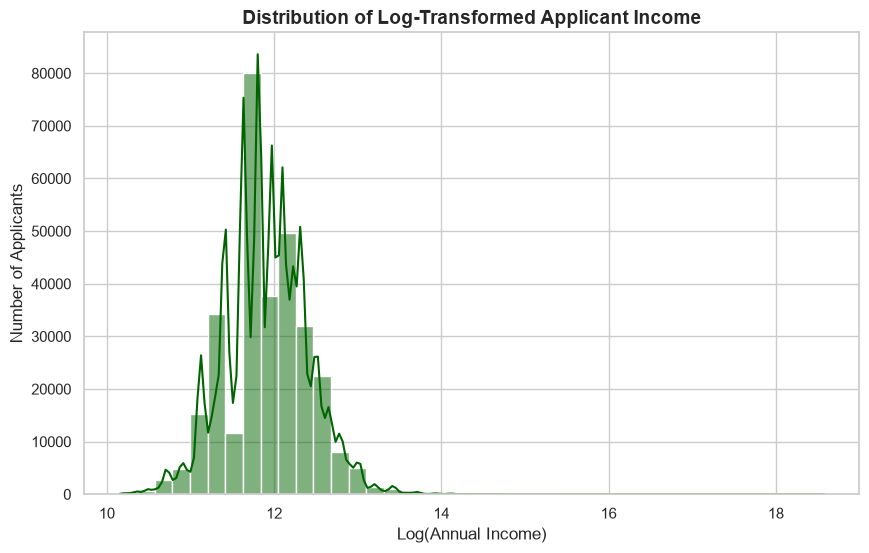

In [361]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="LOG_INCOME",
    bins=40,
    kde=True,
    color="darkgreen"
)

plt.title(
    "Distribution of Log-Transformed Applicant Income",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Log(Annual Income)")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

The raw income distribution is highly right-skewed and dominated by a small number of extremely high-income applicants.

As a result, the majority of observations are compressed into a narrow region of the histogram, making the underlying distribution difficult to interpret.

### Business Interpretation

Large differences in applicant income are expected within a lending portfolio because customers come from diverse economic backgrounds.

High-income applicants should not be treated as errors solely because they are rare, as they may represent legitimate borrowers with substantial repayment capacity.

### Business Interpretation

Large differences in applicant income are expected within a lending portfolio because customers come from diverse economic backgrounds.

High-income applicants should not be treated as errors solely because they are rare, as they may represent legitimate borrowers with substantial repayment capacity.

## 3.1.2 Income Distribution using Boxplot

### Objective

A boxplot provides a concise summary of the income distribution by highlighting the median, quartiles, spread, and potential outliers.

This analysis helps determine whether applicant income contains unusually high values that may require transformation or special treatment before model development.

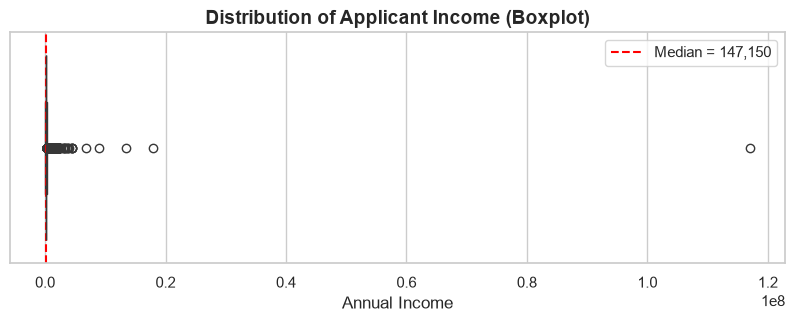

In [362]:
plt.figure(figsize=(10,3))

ax = sns.boxplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    color="seagreen"
)

median_income = df["AMT_INCOME_TOTAL"].median()

plt.axvline(
    median_income,
    color="red",
    linestyle="--",
    label=f"Median = {median_income:,.0f}"
)

plt.title(
    "Distribution of Applicant Income (Boxplot)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Annual Income")
plt.legend()

plt.show()

### Observation

The income boxplot reveals a highly right-skewed distribution with numerous high-income outliers.

Most applicants are concentrated within a relatively narrow income range around the median income of **147,150**, while a small number of applicants report exceptionally high annual incomes.

#### 3.1.2.1 Additional Analysis(Income Quantiles)

In [363]:
df['AMT_INCOME_TOTAL'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25    112500.0
0.50    147150.0
0.75    202500.0
0.90    270000.0
0.95    337500.0
0.99    472500.0
Name: AMT_INCOME_TOTAL, dtype: float64

### Observation

The percentile analysis indicates that **50%** of applicants earn **₹147,150 or less**, while **75%** earn below **₹202,500** annually. Furthermore, **99%** of applicants have an annual income below **₹472,500**, which is substantially lower than the maximum reported income. This confirms that the income distribution is heavily influenced by a very small number of exceptionally high-income applicants, explaining the strong positive skewness observed earlier.

### Business Interpretation

The presence of high-income outliers reflects the diversity of borrowers within the bank's customer portfolio.

These observations are not necessarily errors, as they may represent business owners, senior executives, or other high-net-worth individuals. Therefore, they should be retained rather than removed solely because they are uncommon.

### Key Takeaway

Applicant income contains substantial positive skew driven by a relatively small number of high-income borrowers. These observations represent valid customer segments and should be handled through appropriate transformations rather than removed from the dataset.

# 3.1.3 Default Rate by Income Group

In [364]:
# Create income quartiles
df["INCOME_GROUP"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=4,
    labels=[
        "Low",
        "Lower-Middle",
        "Upper-Middle",
        "High"
    ]
)

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\4204419671.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["INCOME_GROUP"] = pd.qcut(


In [365]:
df["INCOME_GROUP"].value_counts().sort_index()

INCOME_GROUP
Low             100578
Lower-Middle     53182
Upper-Middle     82213
High             71538
Name: count, dtype: int64

In [366]:
income_default_rate = (
    df.groupby("INCOME_GROUP")["TARGET"]
      .mean()
      .mul(100)
)

income_default_rate

INCOME_GROUP
Low             8.394480
Lower-Middle    8.531082
Upper-Middle    8.395266
High            6.909614
Name: TARGET, dtype: float64

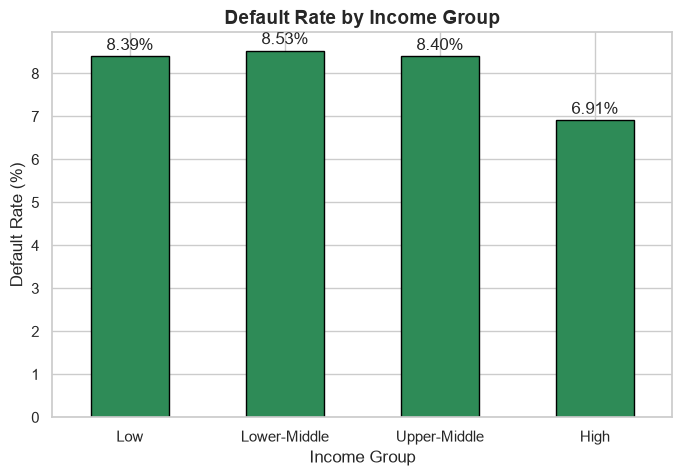

In [367]:
plt.figure(figsize=(8,5))

ax = income_default_rate.plot(
    kind="bar",
    color="seagreen",
    edgecolor="black"
)

plt.title(
    "Default Rate by Income Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(income_default_rate):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

### Observation

Default rates remain relatively similar across the Low, Lower-Middle, and Upper-Middle income groups, ranging from approximately **8.39% to 8.53%**.

A more noticeable decline is observed only in the **High-income** group, where the default rate decreases to **6.91%**.

### Business Interpretation

Income alone does not appear to strongly differentiate credit risk across the majority of applicants.

However, borrowers in the highest income group exhibit a lower default rate, suggesting that higher earnings may provide greater financial resilience and repayment capacity during periods of financial stress.

### Credit Risk Insight

Although applicant income is an important financial characteristic, this analysis suggests that its relationship with default risk is not strictly linear across all income levels.

Income is therefore likely to provide greater predictive value when combined with other variables such as credit amount, employment status, loan-to-income ratio, and existing debt obligations.

### Key Takeaway

Higher income is associated with lower default risk, but the effect becomes most apparent only among the highest-income applicants. This suggests that applicant income should not be evaluated in isolation but rather in conjunction with other financial indicators when assessing credit risk.                        

## 3.2 Credit Amount Analysis

### 3.2.1 Credit Amount Distribution

### Objective

### Business Context

Before approving a loan, banks determine not only whether an applicant is creditworthy but also how much credit can be safely extended. Larger loan amounts increase the bank's financial exposure, making it important to understand how approved credit amounts are distributed across the portfolio.

### Objective

The approved credit amount represents the bank's financial exposure to each borrower and is one of the most important variables in credit risk assessment.

In this section, we examine the distribution of approved loan amounts, identify potential outliers, and assess whether the variable requires preprocessing before model development.

In [368]:
# Summary statistics for approved credit amount
df["AMT_CREDIT"].describe().round(2)

count     307511.00
mean      599026.00
std       402490.78
min        45000.00
25%       270000.00
50%       513531.00
75%       808650.00
max      4050000.00
Name: AMT_CREDIT, dtype: float64

In [369]:
print("Skewness:", round(df["AMT_CREDIT"].skew(), 2))

Skewness: 1.23


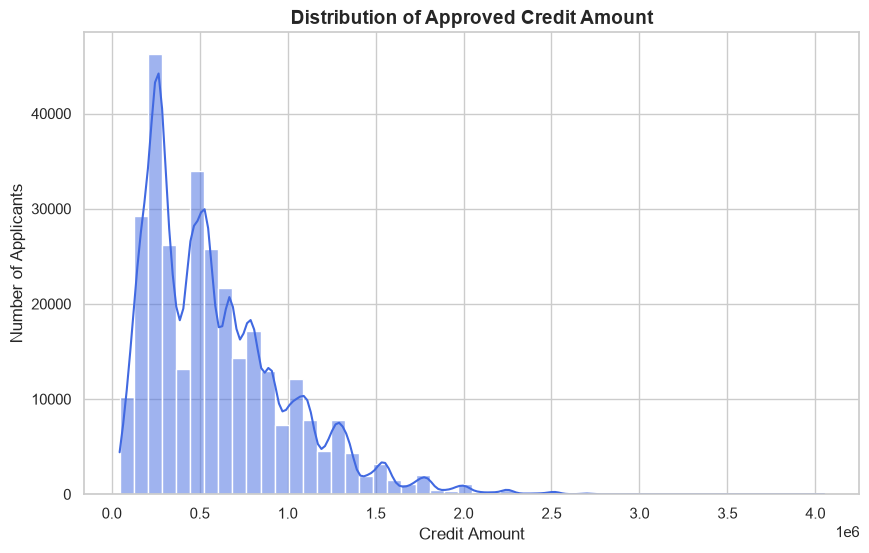

In [370]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AMT_CREDIT",
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title(
    "Distribution of Approved Credit Amount",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Credit Amount")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

The approved credit amount exhibits a moderately right-skewed distribution, with most loans concentrated below approximately 1 million.

Unlike applicant income, the distribution displays several distinct peaks, suggesting that approved loan amounts tend to cluster around common lending values or standard financing products.

A relatively small number of large loans extend the right tail of the distribution.

### Business Interpretation

The concentration of applicants around specific credit amounts suggests that the bank frequently approves loans within predefined lending ranges.

Higher credit amounts represent greater financial exposure for the bank. Consequently, even if high-value loans are less common, they may contribute disproportionately to potential credit losses in the event of borrower default.

### Credit Risk Insight

Although the credit amount distribution is moderately skewed, it is considerably less extreme than the applicant income distribution.

The variable appears suitable for predictive modeling and is expected to provide important information regarding the bank's exposure. Later analyses should examine how loan size interacts with applicant income and repayment capacity rather than considering credit amount in isolation.

### Key Takeaway

Approved credit amounts are concentrated around several common lending levels and exhibit only moderate positive skewness. While larger loans are relatively uncommon, they represent greater financial exposure and therefore remain an important variable for credit risk modeling.

## 3.2.2 Credit Amount Distribution using Boxplot

### Objective

A boxplot summarizes the distribution of approved credit amounts by displaying the median, interquartile range, spread, and potential outliers.

This visualization helps identify whether unusually large loans exist within the portfolio and whether they require special consideration during exploratory analysis or model development.

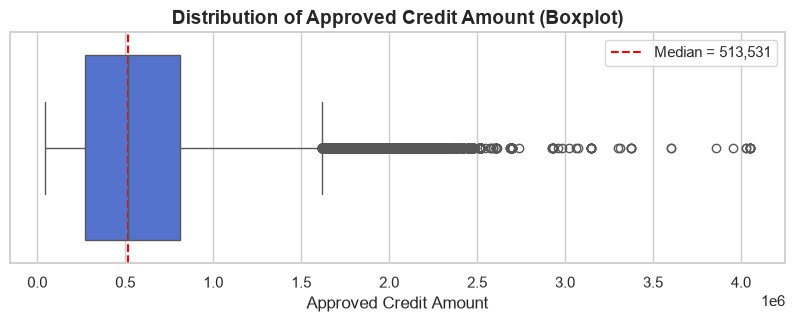

In [371]:
plt.figure(figsize=(10,3))

ax = sns.boxplot(
    data=df,
    x="AMT_CREDIT",
    color="royalblue"
)

median_credit = df["AMT_CREDIT"].median()

plt.axvline(
    median_credit,
    color="red",
    linestyle="--",
    label=f"Median = {median_credit:,.0f}"
)

plt.title(
    "Distribution of Approved Credit Amount (Boxplot)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Approved Credit Amount")
plt.legend()

plt.show()

### Observation

The boxplot indicates that most approved credit amounts are concentrated within a moderate range around the median value of **513,531**.

Several high-value loans appear as outliers beyond the upper whisker, indicating that a relatively small proportion of applicants receive substantially larger credit amounts than the majority of borrowers.

#### 3.2.2.1 Additional Analysis (Credit Amount Quantiles)

In [372]:
df['AMT_CREDIT'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25     270000.0
0.50     513531.0
0.75     808650.0
0.90    1133748.0
0.95    1350000.0
0.99    1854000.0
Name: AMT_CREDIT, dtype: float64

### Observation

The percentile analysis shows that **50%** of applicants have a credit amount of **₹513,531 or less**, while **75%** receive loans below **₹808,650**. Furthermore, **99%** of approved credit amounts are below **₹1,854,000**, indicating that only a very small proportion of applicants receive exceptionally large loans. This confirms the presence of a right-skewed distribution with a limited number of high-value credit outliers.

### Business Interpretation

The presence of higher-value loans reflects the bank's willingness to finance customers with varying borrowing requirements.

Although these larger loans are less common, they expose the bank to greater financial risk because the potential monetary loss associated with a default increases with the loan amount.

### Credit Risk Insight

Unlike applicant income, the approved credit amount exhibits only moderate positive skewness. The observed outliers appear to represent legitimate high-value loans rather than obvious data anomalies.

These observations should be retained because they provide valuable information regarding the bank's credit exposure and may improve the predictive performance of credit risk models.

### Key Takeaway

Approved credit amounts vary considerably across borrowers, with a relatively small number of high-value loans extending the upper tail of the distribution. Since larger loans increase the bank's financial exposure, credit amount is expected to remain an important predictor in subsequent risk modeling.

## 3.2.3 Default Rate by Credit Amount Group

### Business Context

The size of an approved loan determines the bank's financial exposure. While larger loans involve greater monetary risk, they are often granted to applicants with stronger financial profiles. Understanding whether default rates differ across loan sizes helps evaluate whether credit amount alone is associated with repayment behavior.

### Objective

Understanding whether default rates vary across different loan sizes helps determine whether larger loans are associated with greater credit risk.

To ensure fair comparisons, approved credit amounts are divided into quartiles so that each group contains approximately the same number of applicants.

In [373]:
# Create credit amount quartiles
df["CREDIT_GROUP"] = pd.qcut(
    df["AMT_CREDIT"],
    q=4,
    labels=[
        "Low",
        "Lower-Middle",
        "Upper-Middle",
        "High"
    ]
)

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\2897797152.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_GROUP"] = pd.qcut(


In [374]:
df["CREDIT_GROUP"].value_counts().sort_index()

CREDIT_GROUP
Low             78421
Lower-Middle    75428
Upper-Middle    77786
High            75876
Name: count, dtype: int64

In [375]:
credit_default_rate = (
    df.groupby("CREDIT_GROUP", observed=False)["TARGET"]
      .mean()
      .mul(100)
      .round(2)
)

credit_default_rate

CREDIT_GROUP
Low             7.24
Lower-Middle    9.68
Upper-Middle    9.16
High            6.21
Name: TARGET, dtype: float64

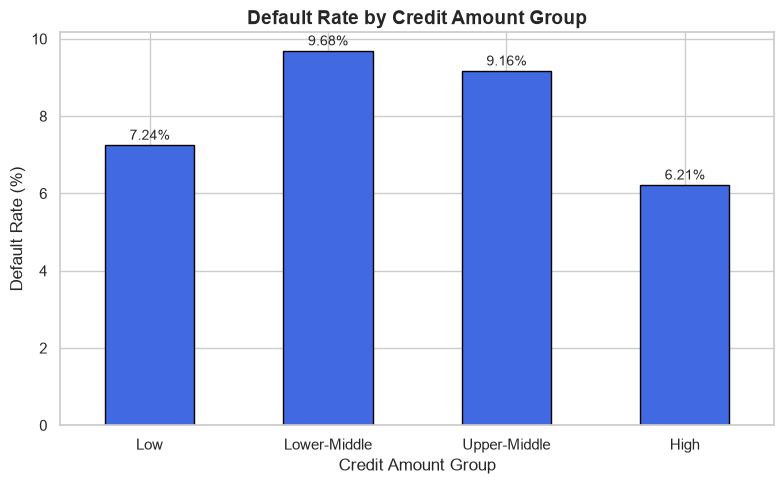

In [376]:
plt.figure(figsize=(8,5))

ax = credit_default_rate.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Default Rate by Credit Amount Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Credit Amount Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(credit_default_rate):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Observation

Default rates vary across different credit amount groups rather than following a simple increasing trend.

Applicants in the **Lower-Middle** and **Upper-Middle** credit groups exhibit the highest default rates at **9.68%** and **9.16%**, respectively.

In contrast, borrowers receiving the **highest credit amounts** have the lowest default rate (**6.21%**).

### Business Interpretation

The results suggest that larger loan amounts do not necessarily correspond to higher credit risk.

Banks often approve larger loans only for applicants who demonstrate stronger financial profiles, higher repayment capacity, or better credit histories. Consequently, borrowers receiving the highest loan amounts may actually represent lower-risk customers despite the bank's greater financial exposure.

### Credit Risk Insight

The relationship between approved credit amount and default risk is non-linear.

This finding indicates that credit amount alone is insufficient for assessing borrower risk. Instead, its predictive value is likely enhanced when analyzed alongside applicant income, employment status, previous credit history, and affordability ratios such as the credit-to-income ratio.

### Key Takeaway

Higher approved loan amounts are not associated with higher default rates in this dataset. Instead, the highest credit group exhibits the lowest default rate, suggesting that lending decisions already incorporate borrower quality. Credit amount should therefore be interpreted together with other financial characteristics rather than in isolation.

## 3.3 Annuity Analysis

### Business Context

The annuity represents the regular repayment amount that a borrower must pay throughout the loan period. Unlike the total credit amount, the annuity reflects the immediate repayment burden placed on the borrower and is therefore an important indicator of loan affordability.

Understanding the distribution of annuity payments helps identify typical repayment obligations across the customer portfolio and provides insights into potential repayment risk.

### Objective

This section examines the distribution of applicant annuity amounts, identifies potential outliers, and investigates whether borrowers with different repayment obligations exhibit different default rates.

In [377]:
# Summary statistics for annuity amount
df["AMT_ANNUITY"].describe().round(2)

count    307499.00
mean      27108.57
std       14493.74
min        1615.50
25%       16524.00
50%       24903.00
75%       34596.00
max      258025.50
Name: AMT_ANNUITY, dtype: float64

In [378]:
print("Skewness:", round(df["AMT_ANNUITY"].skew(), 2))

Skewness: 1.58


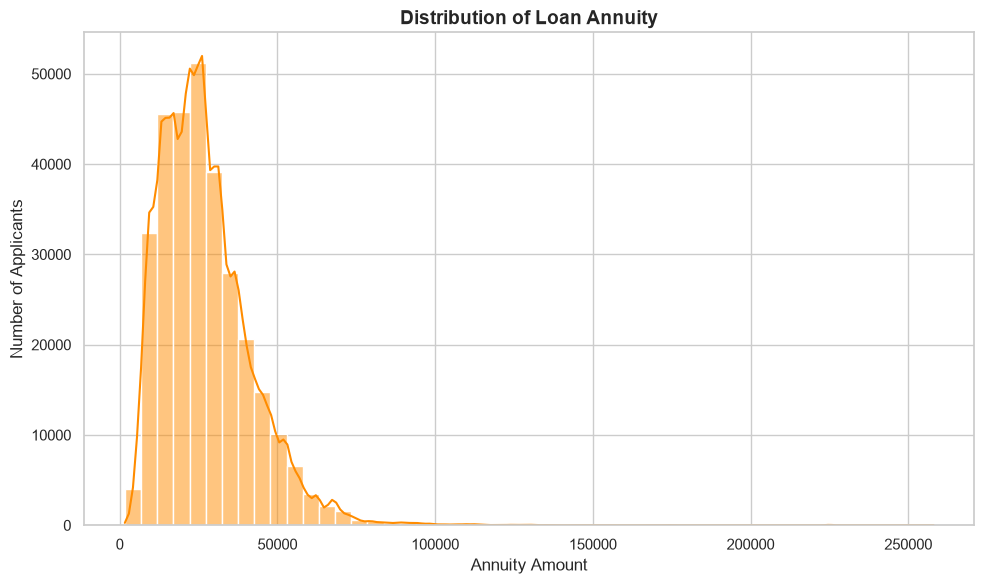

In [379]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AMT_ANNUITY",
    bins=50,
    kde=True,
    color="darkorange"
)

plt.title(
    "Distribution of Loan Annuity",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Annuity Amount")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

### Observation

The distribution of loan annuity amounts is positively skewed, with most applicants having annual repayment obligations between approximately **15,000 and 40,000**.

The median annuity amount is **24,903**, while the mean is slightly higher (**27,109**), indicating the presence of borrowers with relatively large repayment obligations.

Although most customers fall within a moderate repayment range, a small number of applicants have substantially higher annuity amounts, creating a long right tail in the distribution.

### Business Interpretation

Loan annuity reflects the borrower's periodic repayment burden rather than the total loan size. Most borrowers in the portfolio have repayment obligations that appear manageable relative to typical consumer lending products.

Applicants with unusually high annuity payments may either have received larger loans or selected shorter repayment periods, increasing their monthly repayment commitments and potentially their financial stress.

### Credit Risk Insight

Annuity amount is an important indicator of repayment capacity. Higher repayment obligations can increase financial pressure on borrowers, particularly when combined with low income or existing financial commitments.

This variable is therefore expected to contribute meaningful predictive information in credit risk models when evaluated alongside income and credit amount.

### Key Takeaway

Most applicants have moderate repayment obligations, while a relatively small group carries significantly larger annuity payments. The relationship between annuity size and default behavior will be explored in the following analysis to determine whether larger repayment burdens are associated with higher credit risk.

# 3.3.1 Boxplot of Annuity

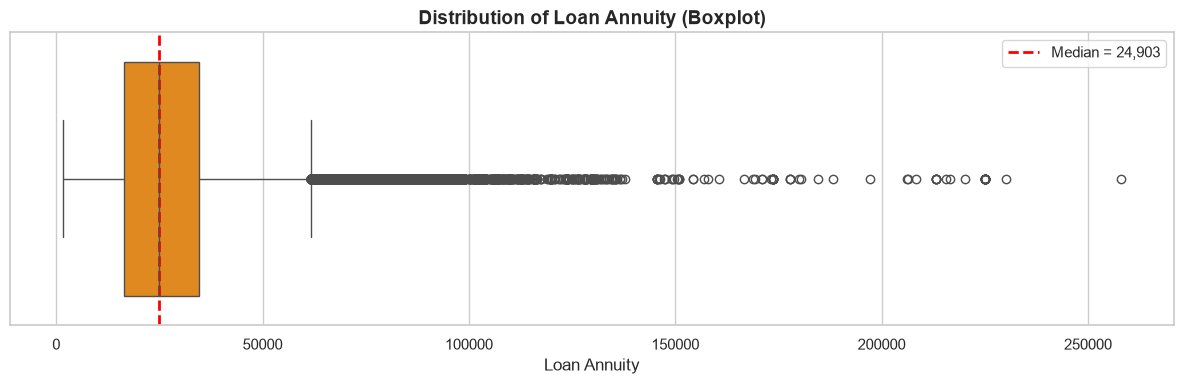

In [380]:
plt.figure(figsize=(12, 4))

median_annuity = df["AMT_ANNUITY"].median()

sns.boxplot(
    x=df["AMT_ANNUITY"],
    color="darkorange"
)

plt.axvline(
    median_annuity,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_annuity:,.0f}"
)

plt.title(
    "Distribution of Loan Annuity (Boxplot)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Loan Annuity")
plt.legend()

plt.tight_layout()
plt.show()

### Observation

The boxplot confirms that loan annuity amounts are positively skewed. The median annuity is approximately **24,903**, while most borrowers have repayment obligations below **40,000**.

A large number of observations appear as outliers on the upper side, with some annuity amounts exceeding **250,000**, indicating a small group of borrowers with exceptionally high repayment obligations.

#### 3.3.1.2 Additional Analysis (Loan Annuity Quantiles)

In [381]:
df['AMT_ANNUITY'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25    16524.0
0.50    24903.0
0.75    34596.0
0.90    45954.0
0.95    53325.0
0.99    70006.5
Name: AMT_ANNUITY, dtype: float64

### Observation

The percentile analysis indicates that **50%** of applicants have a loan annuity of **₹24,903 or less**, while **75%** pay an annual annuity below **₹34,596**. Additionally, **99%** of applicants have annuity amounts below **₹70,006.5**, suggesting that only a very small proportion of borrowers have exceptionally high repayment obligations. This confirms that the annuity distribution is moderately right-skewed, with a limited number of high-value outliers.

### Business Interpretation

Most customers have moderate repayment commitments that are consistent with standard retail lending products.

The relatively small number of borrowers with very high annuity amounts likely corresponds to larger loans or shorter repayment periods. These customers may require closer affordability assessment because higher periodic payments can increase repayment pressure.

### Credit Risk Insight

Although high annuity values are statistically identified as outliers, they are likely genuine observations rather than data errors. In credit risk modelling, these observations should generally be retained because they represent customers with substantially different financial obligations and may contain valuable predictive information.

### Key Takeaway

Loan annuity exhibits significant upper-tail outliers while the majority of borrowers maintain moderate repayment obligations. This variable is expected to play an important role in assessing repayment capacity and predicting default risk when combined with applicant income and loan amount.

# 3.3.2 — Default Rate by Annuity Group

In [382]:
# Create four equal-sized annuity groups

df["ANNUITY_GROUP"] = pd.qcut(
    df["AMT_ANNUITY"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\569719521.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_GROUP"] = pd.qcut(


In [383]:
df["ANNUITY_GROUP"].value_counts().sort_index()

ANNUITY_GROUP
Low             76893
Lower-Middle    76880
Upper-Middle    76962
High            76764
Name: count, dtype: int64

In [384]:
annuity_default_rate = (
    df.groupby("ANNUITY_GROUP", observed=False)["TARGET"]
      .mean()
      .mul(100)
      .round(2)
)

annuity_default_rate

ANNUITY_GROUP
Low             7.06
Lower-Middle    8.75
Upper-Middle    9.23
High            7.24
Name: TARGET, dtype: float64

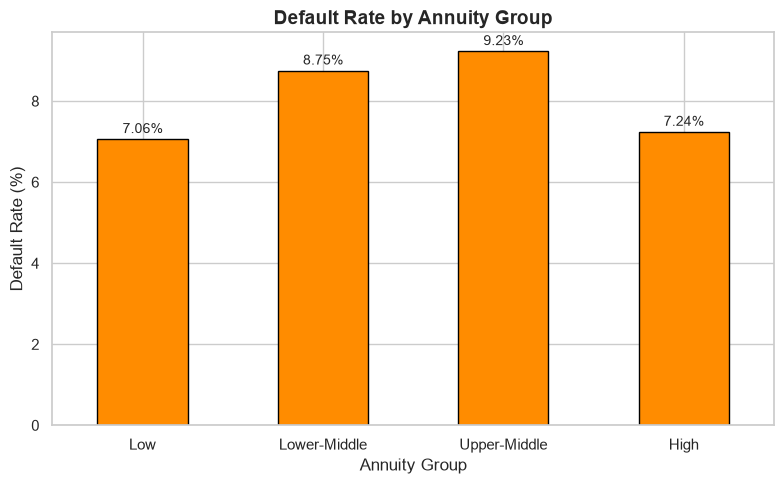

In [385]:
plt.figure(figsize=(8,5))

ax = annuity_default_rate.plot(
    kind="bar",
    color="darkorange",
    edgecolor="black"
)

plt.title(
    "Default Rate by Annuity Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Annuity Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(annuity_default_rate):
    plt.text(i, value + 0.15, f"{value:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### Observation

The default rate varies across annuity groups rather than increasing steadily with repayment obligations.

Borrowers in the **Upper-Middle** annuity group exhibit the highest default rate (9.23%), followed by the **Lower-Middle** group (8.75%). In contrast, applicants with the **highest annuity amounts** have a relatively lower default rate (7.24%), which is close to that of the lowest annuity group (7.06%).

### Business Interpretation

The findings suggest that repayment burden alone does not determine credit risk.

Applicants with the largest annuity payments may also possess stronger financial profiles, such as higher incomes or better repayment capacity, allowing them to manage larger repayment obligations. Therefore, annuity should always be interpreted alongside income and loan size rather than in isolation.

### Credit Risk Insight

This analysis highlights that the relationship between annuity amount and default is non-linear.

Instead of assuming that larger repayment obligations automatically increase default risk, the model should learn the interaction between annuity, income, credit amount, and other financial variables. Such interactions are often captured effectively by tree-based machine learning models.

### Key Takeaway

Moderate annuity groups exhibit the highest default rates, whereas applicants with the largest repayment obligations do not necessarily pose the greatest credit risk. This indicates that repayment capacity depends on multiple financial characteristics rather than annuity amount alone.

# 3.4 Goods Price Analysis

### Business Context

The **Goods Price (`AMT_GOODS_PRICE`)** represents the market value of the asset or product being financed through the loan, such as a house, car, or consumer goods. Comparing the goods price with the requested credit amount helps assess whether borrowers are financing the full value of the asset or making an upfront contribution. Understanding the distribution of goods prices provides insights into the types of assets financed and their potential relationship with credit risk.

In [386]:
df['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

### Observation

The **AMT_GOODS_PRICE** variable contains information for **307,233** applicants, with only **278 missing values**, indicating that the dataset is nearly complete. The average goods price is approximately **₹538,396**, while the median value is **₹450,000**, suggesting that the distribution is influenced by higher-priced assets. Goods prices range from **₹40,500** to **₹4,050,000**, reflecting substantial variation in the value of financed assets.

In [387]:
df['AMT_GOODS_PRICE'].isnull().sum()

np.int64(278)

### Observation

The **AMT_GOODS_PRICE** variable contains only **278 missing values**, representing a very small proportion of the dataset. This indicates that goods price information is available for almost all applicants and is unlikely to pose significant challenges during subsequent data analysis and feature engineering.

In [388]:
df['AMT_GOODS_PRICE'].skew()

np.float64(1.349000341474745)

### Observation

The skewness value of **1.35** indicates that the goods price distribution is **positively skewed**. Most applicants finance assets with relatively moderate prices, while a smaller number of applicants purchase substantially higher-priced goods, resulting in a longer right tail in the distribution.

### 3.4.1 Distribution Analysis

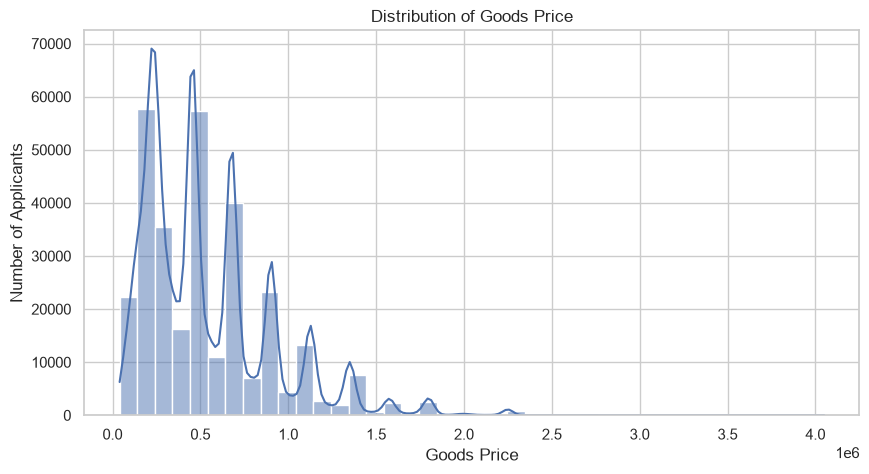

In [389]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['AMT_GOODS_PRICE'],
    bins=40,
    kde=True
)

plt.title("Distribution of Goods Price")
plt.xlabel("Goods Price")
plt.ylabel("Number of Applicants")

plt.show()

### Observation

The distribution of **AMT_GOODS_PRICE** is positively skewed, with most financed goods concentrated in the lower and middle price ranges. The frequency of applicants gradually decreases as the goods price increases, while only a small number of applicants finance very high-value assets. This indicates that the majority of Home Credit customers purchase moderately priced goods.

### 3.4.2 Boxplot Analysis

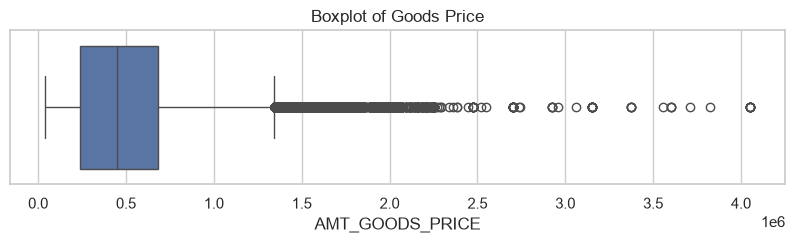

In [390]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df['AMT_GOODS_PRICE']
)

plt.title("Boxplot of Goods Price")

plt.show()

### Observation

The boxplot confirms the presence of several high-value outliers beyond the upper whisker. Although most applicants finance goods within a relatively moderate price range, a small proportion purchase significantly more expensive assets. These outliers contribute to the right-skewed nature of the goods price distribution.

### 3.4.2.1 Additional Analysis (Goods Price Quantiles) 

In [391]:
df['AMT_GOODS_PRICE'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25     238500.0
0.50     450000.0
0.75     679500.0
0.90    1093500.0
0.95    1305000.0
0.99    1800000.0
Name: AMT_GOODS_PRICE, dtype: float64

### Observation

The quantile analysis shows that **75%** of financed goods are priced below **₹679,500**, while **90%** are below **₹1,093,500**. Only the top **1%** of applications involve goods priced above **₹1,800,000**, confirming that extremely high-value purchases are relatively uncommon within the portfolio.

### Business Interpretation

Most applicants finance goods of moderate value, indicating that Home Credit primarily serves customers purchasing affordable consumer assets. Although high-value financed goods exist, they represent only a small fraction of the customer base and may require additional credit assessment due to their larger financial exposure.

### Key Credit Risk Insight 
Goods price represents the value of the financed asset and directly influences the lender's exposure. Higher-value purchases may involve larger loan amounts and potentially higher repayment risk, making **AMT_GOODS_PRICE** an important variable for credit risk assessment and predictive modeling.

# 3.4.3 Default Rate by Goods Price Group

In [392]:
goods_bins = [0, 250000, 500000, 750000, 1000000, df['AMT_GOODS_PRICE'].max()]

goods_labels = [
    'Up to 250K',
    '250K-500K',
    '500K-750K',
    '750K-1M',
    'Above 1M'
]

df['GOODS_PRICE_GROUP'] = pd.cut(
    df['AMT_GOODS_PRICE'],
    bins=goods_bins,
    labels=goods_labels,
    include_lowest=True
)

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\1547344794.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['GOODS_PRICE_GROUP'] = pd.cut(


In [393]:
df['GOODS_PRICE_GROUP'].value_counts().sort_index()

GOODS_PRICE_GROUP
Up to 250K    84891
250K-500K     97727
500K-750K     57883
750K-1M       32613
Above 1M      34119
Name: count, dtype: int64

In [394]:
goods_default = (
    df.groupby('GOODS_PRICE_GROUP')['TARGET']
      .mean()
      .reset_index()
)

goods_default

,GOODS_PRICE_GROUP,TARGET
0,Up to 250K,0.079231
1,250K-500K,0.099757
2,500K-750K,0.076896
3,750K-1M,0.066201
4,Above 1M,0.050382


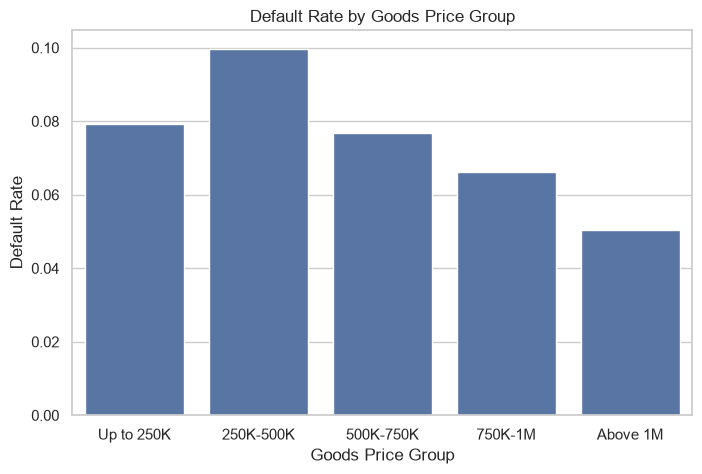

In [395]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=goods_default,
    x='GOODS_PRICE_GROUP',
    y='TARGET'
)

plt.title("Default Rate by Goods Price Group")
plt.xlabel("Goods Price Group")
plt.ylabel("Default Rate")

plt.show()

#### Observation

The default rate is highest among applicants financing goods priced between **250K–500K (9.98%)**. Beyond this range, the default rate steadily declines as the financed goods price increases, reaching the lowest level (**5.04%**) for goods priced above **1M**. This suggests that applicants purchasing higher-value goods generally exhibit stronger repayment performance and lower credit risk.

### Business Interpretation

Applicants financing higher-priced goods are likely to possess stronger financial capacity, resulting in lower observed default rates. In contrast, borrowers purchasing goods in the lower-to-middle price segment (250K–500K) exhibit comparatively higher credit risk. Goods price therefore reflects not only the value of the financed asset but also serves as an indirect indicator of the applicant's financial profile.

### Key Credit Risk Insight
Goods price demonstrates an inverse relationship with default risk beyond the mid-price segment. Applicants financing higher-value goods generally show lower default rates, making **AMT_GOODS_PRICE** a valuable predictor of borrower creditworthiness and an important feature for credit risk modeling.

# 4. Employment Profile & Occupation Analysis

## 4.1.1 Employment Duration Analysis

### Objective

Employment history is an important indicator of financial stability. Borrowers with longer employment histories are generally expected to have more stable income sources and lower repayment risk.

In this section, we examine the distribution of employment duration, identify unusual values, and investigate whether employment length is associated with loan default.

The Home Credit dataset stores unemployed/pensioners using a special value: 365243
This is not 365,243 days of employment (1000 years!). It is a placeholder.
Let's first see how many there are.

In [396]:
(df["DAYS_EMPLOYED"] == 365243).sum()

np.int64(55374)

In [397]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

In [398]:
df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"]) / 365

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\370495545.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"]) / 365


In [399]:
df["EMPLOYMENT_YEARS"].describe().round(2)

count    252137.00
mean          6.53
std           6.41
min          -0.00
25%           2.10
50%           4.52
75%           8.70
max          49.07
Name: EMPLOYMENT_YEARS, dtype: float64

In [400]:
print(
    "Skewness:",
    round(df["EMPLOYMENT_YEARS"].skew(), 2)
)

Skewness: 1.97


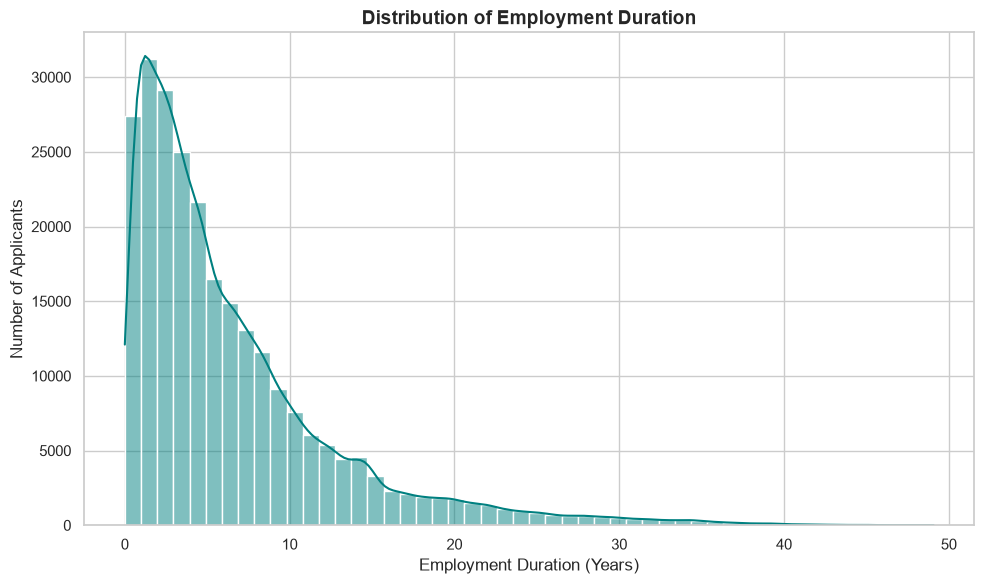

In [401]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="EMPLOYMENT_YEARS",
    bins=50,
    kde=True,
    color="teal"
)

plt.title(
    "Distribution of Employment Duration",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Employment Duration (Years)")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

### Observation

After replacing the placeholder employment values with missing observations, the employment duration distribution shows a clear positive skew.

Most applicants have relatively short employment histories, with the median employment duration being **4.52 years** and the average approximately **6.53 years**. The majority of borrowers have worked for fewer than 10 years, while only a small proportion have employment histories extending beyond 20 years.

The distribution exhibits a long right tail, indicating that a limited number of applicants have very long employment tenures.

### Business Interpretation

Employment duration is commonly viewed as an indicator of income stability and job security. Most customers in the portfolio have relatively limited employment histories, suggesting that the bank serves a large population of early- and mid-career borrowers.

Applicants with longer employment histories are generally expected to have more stable income streams and stronger repayment capacity, although this relationship should be validated through default-rate analysis.

### Credit Risk Insight

Employment duration alone does not determine credit risk, but it provides valuable information about borrower stability. Since the variable is moderately skewed, it may benefit from transformation or tree-based modeling techniques that naturally handle skewed distributions.

This feature is expected to become more informative when combined with variables such as income, occupation, age, and loan amount.

### Key Takeaway

The portfolio is dominated by borrowers with relatively short employment histories, while long-tenure employees represent a much smaller segment. Employment duration is likely to be an informative predictor of credit risk and will be further evaluated by analyzing default rates across employment groups.

# 4.1.2 Employment Duration Boxplot

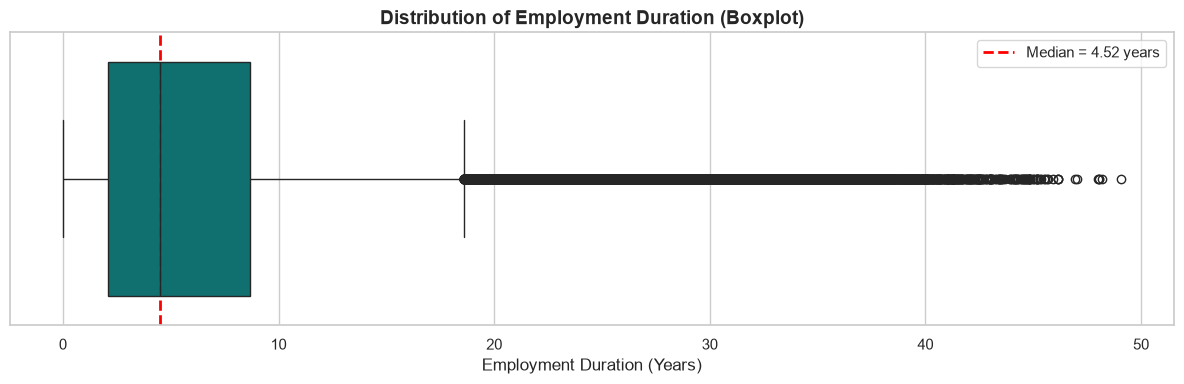

In [402]:
plt.figure(figsize=(12,4))

median_emp = df["EMPLOYMENT_YEARS"].median()

sns.boxplot(
    x=df["EMPLOYMENT_YEARS"],
    color="teal"
)

plt.axvline(
    median_emp,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_emp:.2f} years"
)

plt.title(
    "Distribution of Employment Duration (Boxplot)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Employment Duration (Years)")
plt.legend()

plt.tight_layout()
plt.show()

### Observation

The boxplot confirms that employment duration is positively skewed, with a median employment duration of **4.52 years**.

Most applicants have relatively short employment histories, while a smaller proportion have long employment tenures extending beyond 20 years. These observations appear as statistical outliers but are realistic values rather than data anomalies.

### Business Interpretation

Long employment history generally reflects greater job stability and more consistent income generation. Applicants with several years of continuous employment may be considered financially more stable than recently employed borrowers.

However, employment duration alone should not determine lending decisions, as repayment behavior also depends on income, debt burden, and previous credit history.

### Credit Risk Insight

The presence of long-tenure employees provides useful information for credit risk modeling. Rather than removing these observations, the bank should retain them because they may help distinguish financially stable borrowers from higher-risk applicants.

The actual relationship between employment duration and default risk will be evaluated using default-rate analysis.

### Key Takeaway

Employment duration exhibits a positively skewed distribution with many genuine long-tenure borrowers. Since these values represent real customer behavior, they should be preserved for predictive modeling and further analyzed for their relationship with loan default.

# 4.2 Default Rate by Employment Duration Group

In [403]:
df["EMPLOYMENT_GROUP"] = pd.qcut(
    df["EMPLOYMENT_YEARS"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

df["EMPLOYMENT_GROUP"].value_counts().sort_index()

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\673681756.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_GROUP"] = pd.qcut(


EMPLOYMENT_GROUP
Low             63056
Lower-Middle    63068
Upper-Middle    62980
High            63033
Name: count, dtype: int64

In [404]:
employment_default_rate = (
    df.groupby("EMPLOYMENT_GROUP", observed=False)["TARGET"]
      .mean()
      .mul(100)
      .round(2)
)

employment_default_rate

EMPLOYMENT_GROUP
Low             11.21
Lower-Middle    10.18
Upper-Middle     7.83
High             5.42
Name: TARGET, dtype: float64

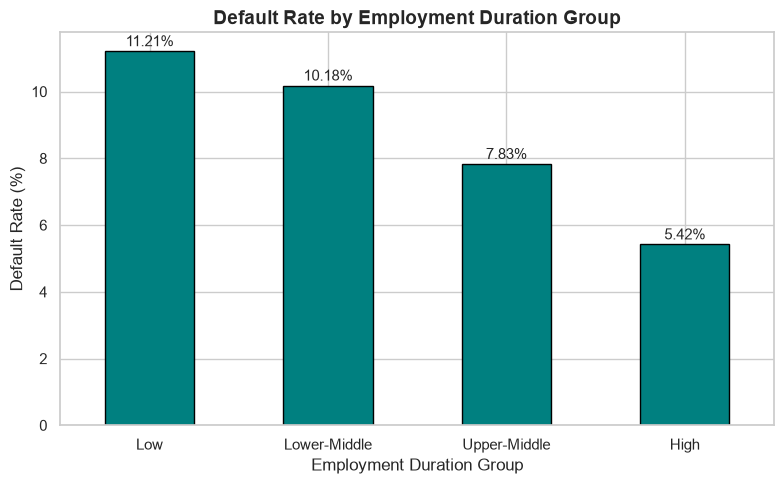

In [405]:
plt.figure(figsize=(8,5))

ax = employment_default_rate.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title(
    "Default Rate by Employment Duration Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Employment Duration Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(employment_default_rate):
    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Observation

The default rate decreases consistently as employment duration increases.

Applicants with the shortest employment history exhibit the highest default rate (11.21%), whereas borrowers with the longest employment duration have the lowest default rate (5.42%).

This clear downward trend indicates a strong inverse relationship between employment duration and loan default.

### Business Interpretation

Long employment history generally reflects stable income, stronger financial discipline, and lower employment uncertainty.

Borrowers with short employment duration may have recently entered the workforce, changed jobs frequently, or have less stable income sources, increasing their probability of repayment difficulties.

Consequently, employment duration serves as an important indicator of borrower reliability during credit assessment.

### Credit Risk Insight

Employment duration demonstrates strong predictive power for credit risk.

Applicants with longer work histories consistently exhibit lower default rates, making employment duration one of the most valuable variables for credit risk modeling and borrower segmentation.

### Key Takeaway

Employment duration is inversely related to default risk. As employment tenure increases, default probability decreases substantially, confirming employment stability as an important predictor of creditworthiness.

## 4.3 Occupation Type Analysis

### Objective

Analyze the distribution of applicant occupations and examine whether default rates differ across occupational groups. This analysis helps identify whether certain professions exhibit higher or lower credit risk.


### Business Context

Occupation provides insight into an applicant's employment stability, earning potential, and financial security. Certain occupations may be associated with more stable income and lower credit risk, while others may experience greater income uncertainty.

Although occupation should not be used as the sole determinant of lending decisions, it provides valuable information when combined with income, employment history, and other financial variables.


In [406]:
df['OCCUPATION_TYPE'].describe()


count       211120
unique          18
top       Laborers
freq         55186
Name: OCCUPATION_TYPE, dtype: object

In [407]:
df['OCCUPATION_TYPE'].isnull().sum()


np.int64(96391)

In [408]:
df['OCCUPATION_TYPE'].value_counts()


OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

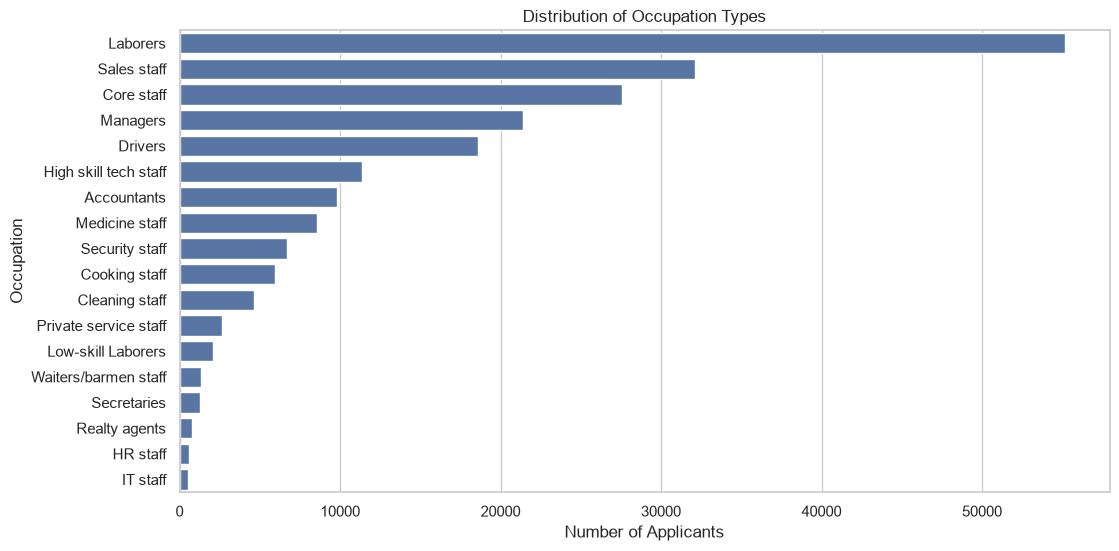

In [409]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='OCCUPATION_TYPE',
    order=df['OCCUPATION_TYPE'].value_counts().index
)

plt.title("Distribution of Occupation Types")
plt.xlabel("Number of Applicants")
plt.ylabel("Occupation")

plt.show()


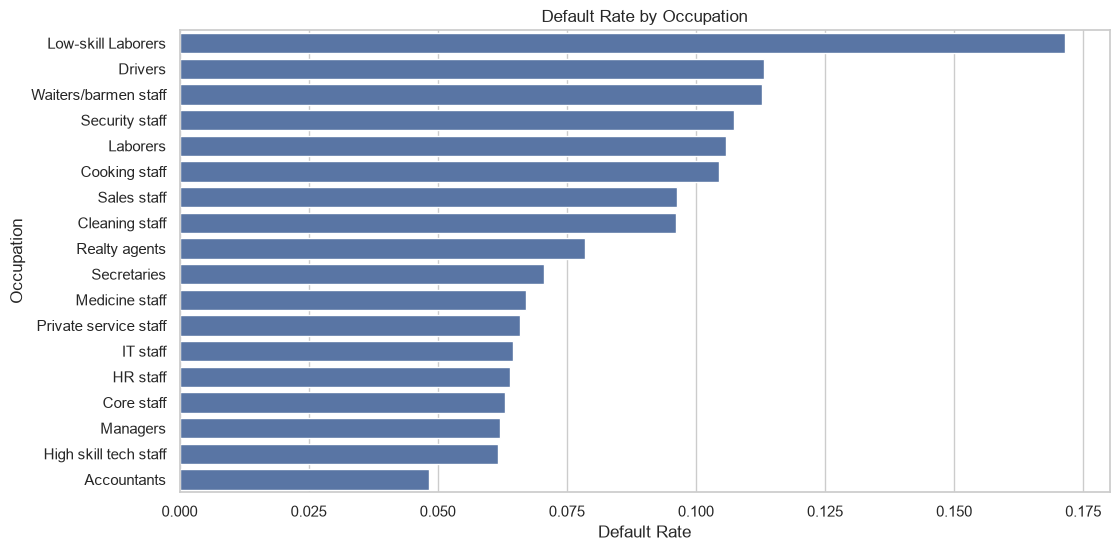

In [410]:
occupation_default = (
    df.groupby('OCCUPATION_TYPE')['TARGET']
      .mean()
      .reset_index()
      .sort_values('TARGET', ascending=False)
)

occupation_default
plt.figure(figsize=(12,6))

sns.barplot(
    data=occupation_default,
    x='TARGET',
    y='OCCUPATION_TYPE'
)

plt.title("Default Rate by Occupation")
plt.xlabel("Default Rate")
plt.ylabel("Occupation")

plt.show()


In [411]:
round(df['OCCUPATION_TYPE'].isnull().mean() * 100, 2)


np.float64(31.35)

Approximately 31.35% of occupation values are missing, indicating that an appropriate imputation strategy will be required during data preprocessing

## Observation

The `OCCUPATION_TYPE` variable contains **96,391 missing values (31.35%)**, indicating that a significant portion of applicants have no recorded occupation. Among the available records, **Laborers** form the largest occupation group. The highest default rates are observed for **Low-skill Laborers**, **Drivers**, **Waiters/Barmen Staff**, and **Security Staff**, while **Accountants**, **High Skill Tech Staff**, and **Managers** exhibit the lowest default rates. This suggests that occupation has a meaningful 

relationship with loan default behavior.
## Business Interpretation

Applicants employed in lower-skilled occupations generally exhibit higher credit risk, whereas professional and skilled occupations show better repayment performance. Since occupation reflects income stability and employment security, it is an important variable for credit risk assessment. The missing occupation values should be handled carefully during data cleaning rather than being removed.


## Key Credit Risk Insight

Occupation is a strong indicator of credit risk. Applicants in lower-skilled occupations such as **Low-skill Laborers, Drivers, and Security Staff** exhibit higher default rates, whereas professional occupations like **Accountants, Managers, and High Skill Tech Staff** demonstrate lower credit risk. Therefore, `OCCUPATION_TYPE` should be retained as an important feature for credit risk modeling, with appropriate treatment of its missing values during data preprocessing.

# 5. Data Quality Analysis

## 5.1 Missing Value Analysis

Missing values are one of the most common data quality issues in real-world financial datasets.

High proportions of missing values may indicate unavailable customer information, optional fields, or data collection issues. Understanding missingness helps determine whether variables should be imputed, transformed, or removed before model development.

In [412]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing / len(df)) * 100, 2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df = missing_df.sort_values("Percentage", ascending=False)

missing_df

,Missing Values,Percentage
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
...,...,...
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00
DAYS_LAST_PHONE_CHANGE,1,0.00
FAMILY_SIZE_GROUP,2,0.00


C:\Users\himan\AppData\Local\Temp\ipykernel_30984\3556172936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


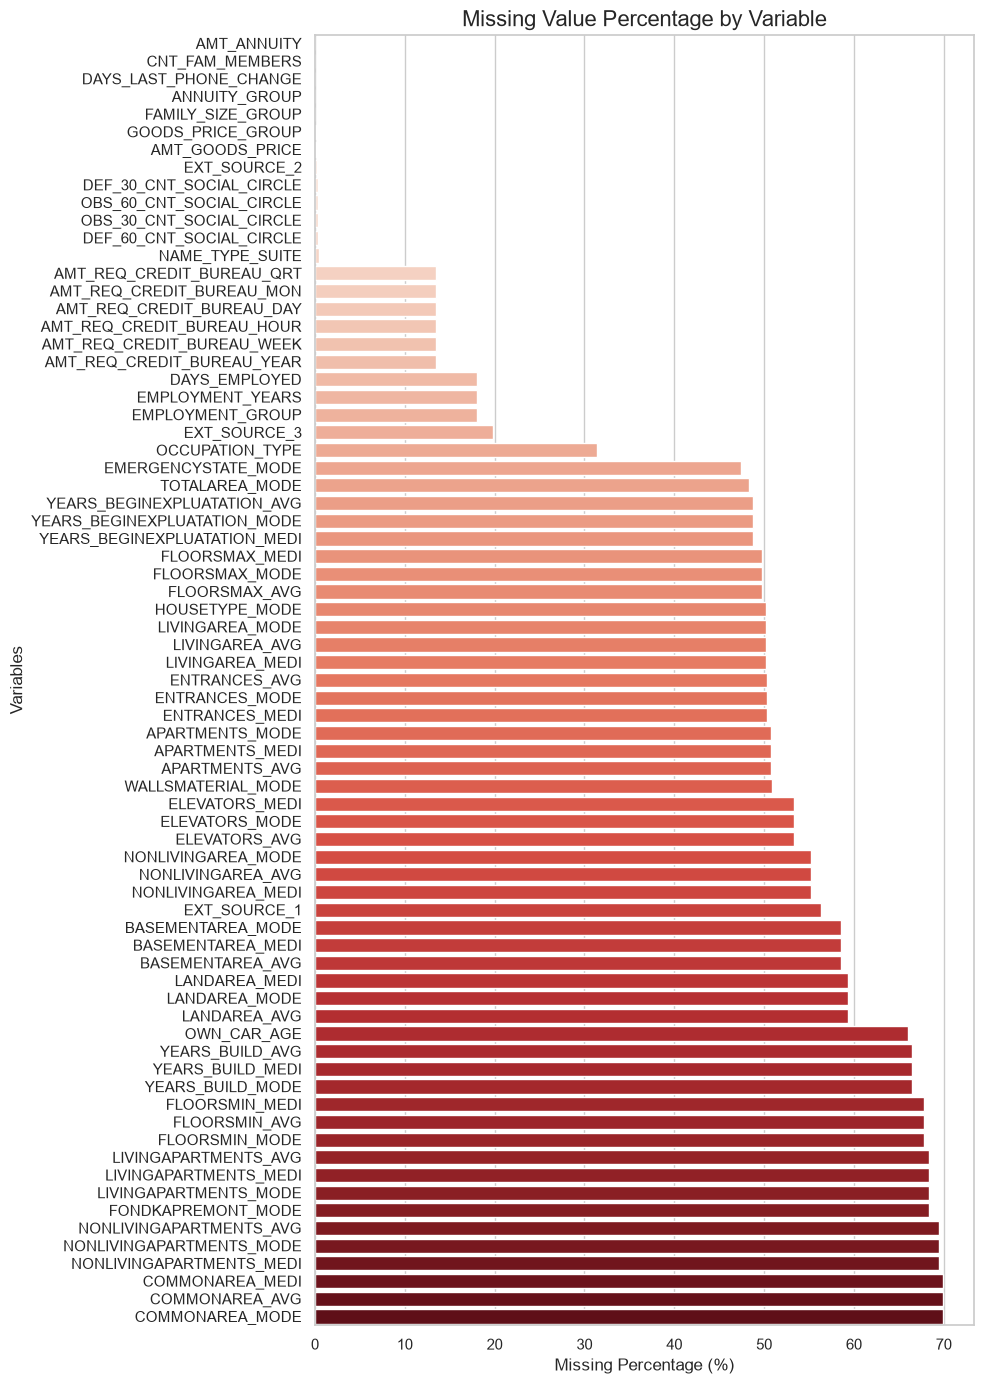

In [413]:
plt.figure(figsize=(10, 14))

missing_df = missing_df.sort_values("Percentage")

sns.barplot(
    data=missing_df,
    x="Percentage",
    y=missing_df.index,
    palette="Reds"
)

plt.title("Missing Value Percentage by Variable", fontsize=16)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

In [414]:
print(f"Total Features with Missing Values: {missing_df.shape[0]}")
print(f"Highest Missing Percentage: {missing_df['Percentage'].max():.2f}%")
print(f"Lowest Missing Percentage: {missing_df['Percentage'].min():.2f}%")

Total Features with Missing Values: 73
Highest Missing Percentage: 69.87%
Lowest Missing Percentage: 0.00%


#### Business Interpretation

- The dataset contains missing values across multiple variables, with several housing-related features exhibiting missing rates above 50%.
- These missing values are expected in real-world lending data, as not all applicants provide complete property or demographic information.
- Variables with extremely high missing percentages should be carefully evaluated before model development. Depending on their predictive value, they may be imputed or removed during the data preprocessing stage.
- Features with low to moderate missingness can be handled using appropriate imputation techniques without significantly affecting model performance.

## 5.2 Duplicate Record Analysis

### Duplicate Record Analysis

Duplicate customer records may introduce bias during model training by giving excessive importance to repeated observations.

Therefore, duplicate records are identified before modeling.

In [415]:
duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)

Total Duplicate Records : 0


In [416]:
if duplicates == 0:
    print("No duplicate records found.")
else:
    print(f"{duplicates} duplicate records need investigation.")

No duplicate records found.


#### Business Interpretation

No duplicate observations indicate that each application represents a unique customer record.

This improves confidence that the dataset accurately represents the applicant population.

## 5.3 Data Type Verification

### Data Type Verification

Correct data types are essential for accurate statistical analysis and machine learning.

This step verifies whether each variable has been stored using an appropriate data type.

In [417]:
dtype_df = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values
})

dtype_df

,Feature,Data Type
0,SK_ID_CURR,int64
1,TARGET,int64
2,NAME_CONTRACT_TYPE,str
3,CODE_GENDER,str
4,FLAG_OWN_CAR,str
...,...,...
128,CREDIT_GROUP,category
129,ANNUITY_GROUP,category
130,GOODS_PRICE_GROUP,category
131,EMPLOYMENT_YEARS,float64


In [418]:
df.dtypes.value_counts()

float64     69
int64       40
str         16
category     4
category     1
category     1
category     1
category     1
Name: count, dtype: int64

#### Business Interpretation

The dataset contains a well-balanced mix of numerical and categorical variables, making it suitable for comprehensive credit risk analysis.

- Numerical features (integer and float) represent applicant demographics, financial information, and credit history, which can be directly used for statistical analysis and predictive modeling.
- Categorical variables capture customer characteristics such as gender, occupation, education, and family status, and will require appropriate encoding before model training.
- The additional `category` data types were created during the EDA process to group continuous variables into meaningful business segments (e.g., age groups, income groups, and goods price groups). These engineered categories improve visualization and business interpretation but may not all be used directly in the final machine learning model.

Overall, the data types are appropriate and require only standard preprocessing steps such as encoding categorical variables and scaling numerical features where necessary.

## 5.4 Unique Value Analysis

### Unique Value Analysis

Understanding the number of unique values helps identify:

- Identifier variables
- Binary variables
- Low-cardinality categorical variables
- High-cardinality variables requiring special encoding

In [419]:
unique_df = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_df = unique_df.sort_values(
    by="Unique Values",
    ascending=False
)

unique_df

,Unique Values
SK_ID_CURR,307511
EXT_SOURCE_2,119831
EXT_SOURCE_1,114584
AGE,17460
DAYS_BIRTH,17460
...,...
FLAG_DOCUMENT_11,2
FLAG_DOCUMENT_8,2
FLAG_DOCUMENT_9,2
FLAG_DOCUMENT_7,2


#### Business Interpretation

- Numerical variables naturally contain many unique values.
- Binary variables such as target labels have only two categories.
- Low-cardinality categorical variables are suitable for one-hot encoding.
- High-cardinality variables may require frequency or target encoding during feature engineering.

## 5.5 Constant and Near-Constant Features

### Constant Feature Analysis

Variables containing only one unique value provide no predictive information and unnecessarily increase model complexity.

These features should be identified before model development.

In [420]:
constant_features = [
    col for col in df.columns
    if df[col].nunique()==1
]

constant_features

[]

In [421]:
print("Number of Constant Features :",len(constant_features))

Number of Constant Features : 0


#### Business Interpretation

No constant features were observed in the cleaned dataset.

Therefore, every feature contributes at least some variation that may be useful during predictive modeling.

## 5.6 Overall Outlier Observation

### Overall Outlier Observation

Several financial variables exhibit extreme values.

These observations are expected in retail lending because a small proportion of applicants possess exceptionally high incomes or request larger loans than the majority of customers.

Rather than immediately removing these observations, they should be evaluated carefully since they may represent legitimate high-value borrowers.

In [422]:
numerical_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    outliers = df[
        (df[col]<lower) |
        (df[col]>upper)
    ].shape[0]

    outlier_summary.append([col,outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Variable","Number of Outliers"]
)

outlier_df.sort_values(
    by="Number of Outliers",
    ascending=False
)

,Variable,Number of Outliers
20,REGION_RATING_CLIENT,80527
21,REGION_RATING_CLIENT_W_CITY,78027
27,REG_CITY_NOT_WORK_CITY,70867
15,FLAG_WORK_PHONE,61308
14,FLAG_EMP_PHONE,55386
...,...,...
17,FLAG_PHONE,0
8,DAYS_BIRTH,0
0,SK_ID_CURR,0
81,FLAG_DOCUMENT_3,0


#### Business Interpretation

The largest number of outliers occurs in financial variables such as income, credit amount, loan annuity, and goods price.

These observations are expected because retail banking portfolios naturally include both low-income customers and high-net-worth individuals.

Future preprocessing may include robust scaling or capping extreme values if necessary.

### Overall Data Quality Summary

The dataset demonstrates good overall quality for predictive modeling.

Key observations include:

- Minimal missing values across most variables.
- No duplicate records.
- Appropriate mix of numerical and categorical features.
- No constant variables.
- Presence of legitimate financial outliers typical in lending datasets.

Overall, the dataset is well-prepared for feature engineering and machine learning after handling missing values and encoding categorical variables.

# 6. Correlation Analysis

Correlation analysis helps identify the strength and direction of linear relationships between numerical variables. It also assists in detecting multicollinearity among predictor variables, which can negatively affect certain machine learning models.

In this section, we examine the correlation structure of the numerical features and identify variables that are strongly associated with each other and with the target variable.

## 6.1 Correlation Matrix

In [423]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Compute Pearson correlation matrix
corr_matrix = numerical_df.corr()

corr_matrix.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE,LOG_INCOME,EMPLOYMENT_YEARS
SK_ID_CURR,1.000000,-0.002108,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,-0.000084,-0.000973,-0.000384,0.001818,0.002804,-0.001337,-0.000415,0.002815,0.002753,0.000281,-0.002895,-0.001075,-0.001138,0.000350,-0.000283,0.001097,0.002903,-0.001885,-0.001582,0.000067,0.000082,0.002342,0.000222,0.001556,-0.002070,0.001551,0.005900,-0.001463,0.004862,-0.002879,0.004851,0.003083,0.001465,0.003119,0.001770,-0.002575,0.003042,0.001961,-0.001411,0.001890,0.005245,-0.001058,0.005017,-0.002844,0.004386,0.002081,0.001548,0.003589,0.002156,-0.001923,0.001920,0.001988,-0.001647,0.001366,0.005777,-0.001036,0.005067,-0.002583,0.004588,0.002837,0.001699,0.003272,0.002205,-0.003020,0.002440,0.002288,-0.001409,-0.000082,-0.001423,0.001187,-0.000858,0.000700,-0.003411,-0.004139,-0.001097,0.002121,-0.002694,0.001809,0.001505,-0.000815,-0.002012,-0.001045,0.000896,-0.001077,0.002604,-0.000724,0.001450,0.000509,0.000167,0.001073,0.000282,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659,0.001500,0.002588,0.000084
TARGET,-0.002108,1.000000,0.019187,-0.003982,-0.030369,-0.012817,-0.039645,-0.037227,0.078239,0.074958,0.041975,0.051457,0.037612,0.000534,0.045982,0.028524,0.000370,-0.023806,-0.001758,0.009308,0.058899,0.060893,-0.024166,0.005576,0.006942,0.002819,0.044395,0.050994,0.032518,-0.155317,-0.160472,-0.178919,-0.029498,-0.022746,-0.009728,-0.022149,-0.018550,-0.034199,-0.019172,-0.044003,-0.033614,-0.010885,-0.025031,-0.032997,-0.003176,-0.013578,-0.027284,-0.019952,-0.009036,-0.022068,-0.016340,-0.032131,-0.017387,-0.043226,-0.032698,-0.010174,-0.023393,-0.030685,-0.001557,-0.012711,-0.029184,-0.022081,-0.009993,-0.022326,-0.018573,-0.033863,-0.019025,-0.043768,-0.033394,-0.011256,-0.024621,-0.032739,-0.002757,-0.013337,-0.032596,0.009131,0.032248,0.009022,0.031276,0.055218,0.005417,0.044346,-0.002672,-0.000316,-0.028602,-0.001520,-0.008040,-0.004352,-0.001414,-0.004229,-0.000756,-0.011583,-0.009464,-0.006536,-0.011615,-0.003378,-0.007952,-0.001358,0.000215,0.003709,0.000930,0.002704,0.000788,-0.01246

# 6.2 Correlation Heatmap

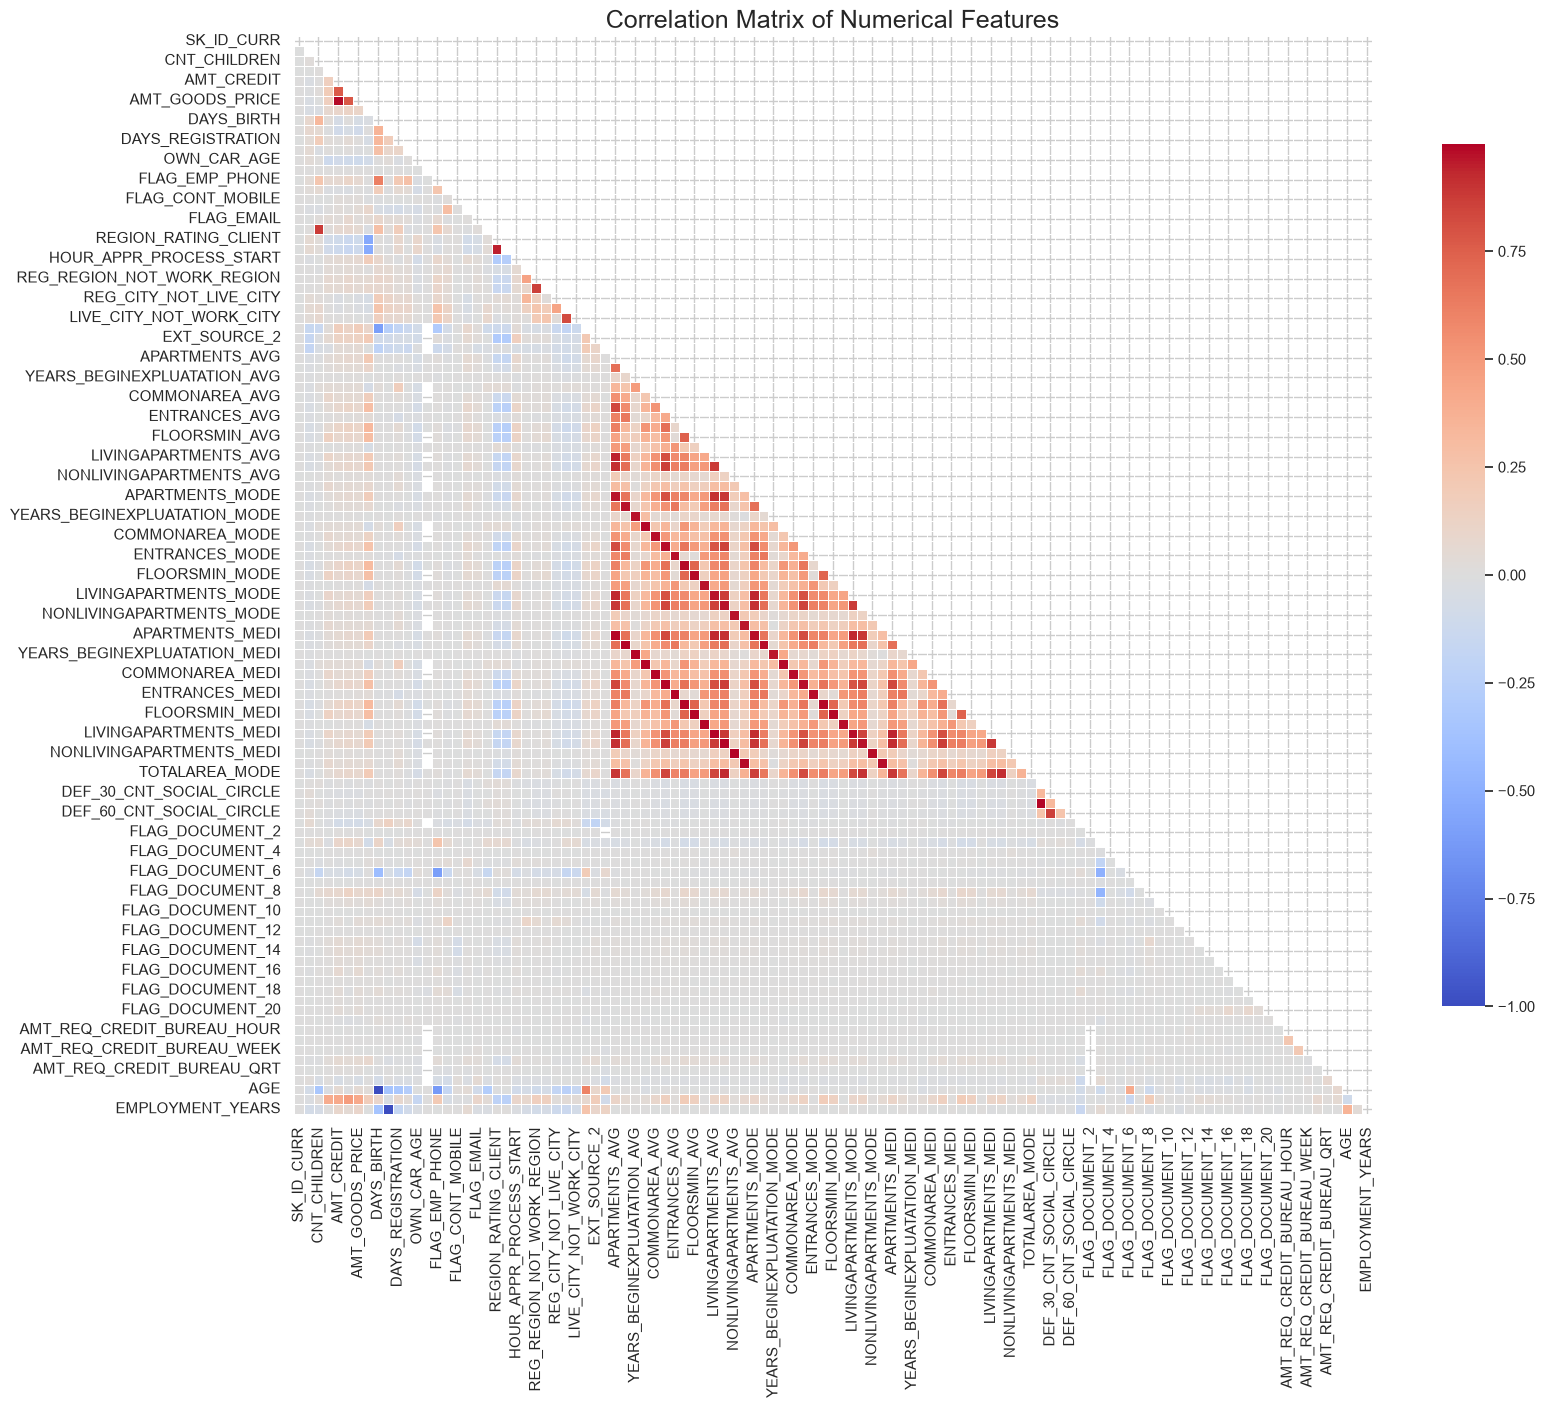

In [424]:
plt.figure(figsize=(18, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=18)

plt.show()

#### Business Interpretation

The correlation heatmap reveals several important relationships among the numerical variables.

- Most variables exhibit weak to moderate correlations, indicating that they provide relatively independent information for credit risk assessment.
- Strong positive correlations are observed among property-related variables (such as apartment size, living area, entrances, and building characteristics), suggesting that these features capture similar aspects of an applicant's property.
- Financial variables, particularly `AMT_CREDIT` and `AMT_GOODS_PRICE`, also demonstrate a strong positive relationship, which is expected because loan amounts are closely linked to the value of financed goods.
- Overall, the dataset does not exhibit excessive multicollinearity across all numerical variables. However, highly correlated property-related features should be examined during feature engineering to avoid redundant information in the predictive model.

# 6.3 Correlation with Target Variable

In [425]:
target_corr = (
    corr_matrix["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

target_corr

EXT_SOURCE_3       -0.178919
EXT_SOURCE_2       -0.160472
EXT_SOURCE_1       -0.155317
AGE                -0.078239
DAYS_BIRTH          0.078239
                      ...   
FLAG_DOCUMENT_12   -0.000756
FLAG_MOBIL          0.000534
FLAG_CONT_MOBILE    0.000370
FLAG_DOCUMENT_5    -0.000316
FLAG_DOCUMENT_20    0.000215
Name: TARGET, Length: 108, dtype: float64

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\2188611309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


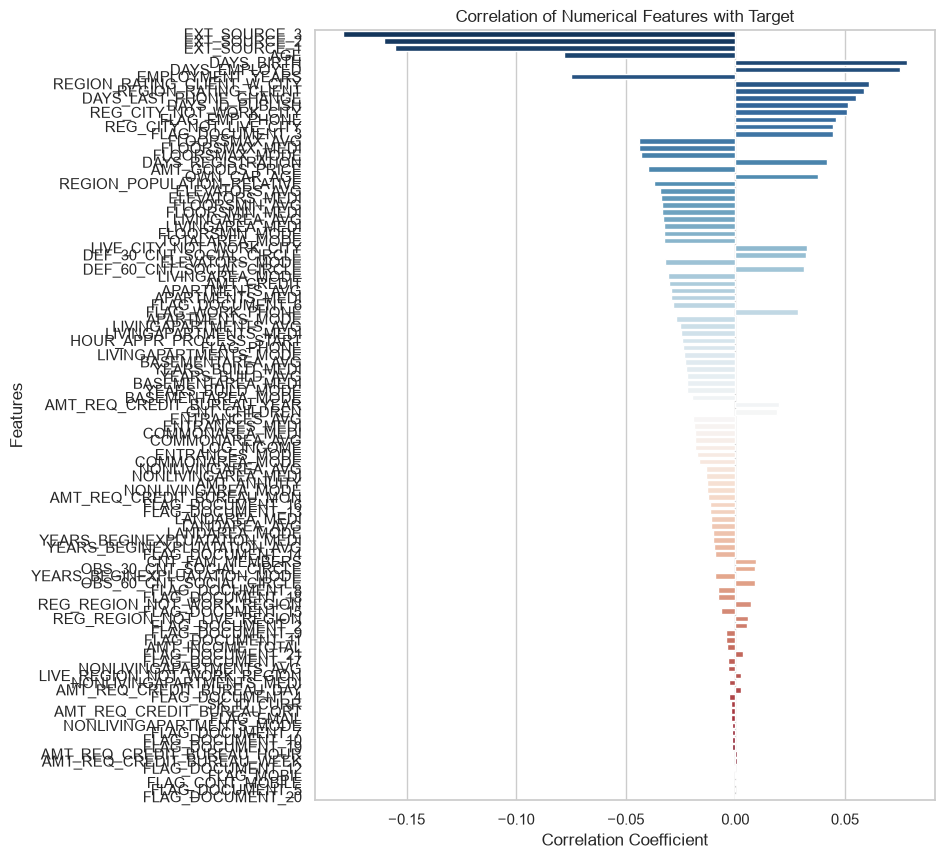

In [426]:
plt.figure(figsize=(8,10))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette="RdBu_r"
)

plt.title("Correlation of Numerical Features with Target")

plt.xlabel("Correlation Coefficient")

plt.ylabel("Features")

plt.show()

C:\Users\himan\AppData\Local\Temp\ipykernel_30984\1860422394.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


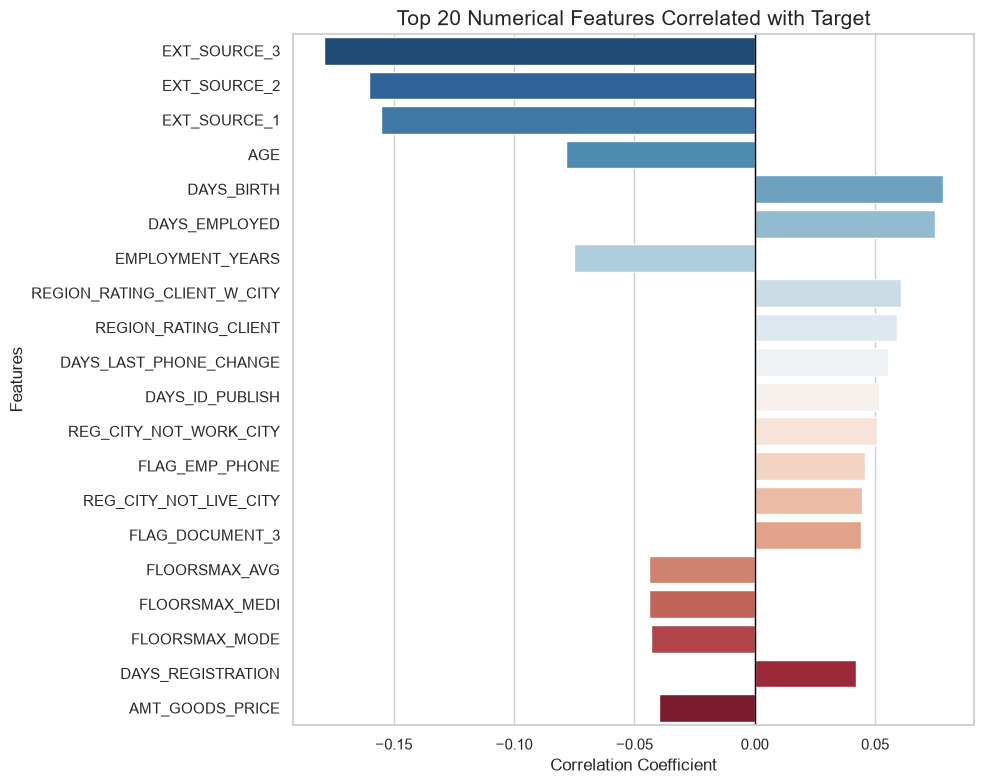

In [427]:
#Showing only top 20 correlation 
# Correlation with target
target_corr = corr_matrix["TARGET"].drop("TARGET")

# Top 20 features with the strongest absolute correlation
top_target_corr = target_corr.reindex(
    target_corr.abs().sort_values(ascending=False).index
).head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=top_target_corr.values,
    y=top_target_corr.index,
    palette="RdBu_r"
)

plt.axvline(0, color='black', linewidth=1)

plt.title("Top 20 Numerical Features Correlated with Target", fontsize=15)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

#### Business Interpretation

The correlation analysis indicates that no single numerical feature has a strong linear relationship with loan default. The highest absolute correlation coefficients remain relatively small, suggesting that default risk is influenced by the combined effect of multiple applicant characteristics rather than any individual variable.

Among the numerical variables, applicant age, employment duration, external credit score variables (`EXT_SOURCE_*`), regional ratings, and selected financial attributes exhibit comparatively stronger relationships with the target variable. These features are therefore likely to contribute meaningful predictive information during model development.

The generally weak correlations also indicate that non-linear machine learning algorithms and feature engineering are likely to capture additional patterns that are not evident through simple Pearson correlation analysis.

# 6.4 Strong Correlation Pairs

In [428]:
corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

strong_corr = corr_pairs[corr_pairs >= 0.70]

strong_corr.drop_duplicates()

EMPLOYMENT_YEARS          DAYS_EMPLOYED               1.000000
DAYS_BIRTH                AGE                         1.000000
YEARS_BUILD_AVG           YEARS_BUILD_MEDI            0.998495
OBS_30_CNT_SOCIAL_CIRCLE  OBS_60_CNT_SOCIAL_CIRCLE    0.998490
FLOORSMIN_AVG             FLOORSMIN_MEDI              0.997241
                                                        ...   
FLOORSMIN_MEDI            FLOORSMAX_MODE              0.729871
FLOORSMIN_AVG             FLOORSMAX_MODE              0.729179
FLOORSMIN_MODE            FLOORSMAX_MODE              0.726334
FLOORSMAX_MEDI            FLOORSMIN_MODE              0.722970
FLOORSMIN_MODE            FLOORSMAX_AVG               0.722243
Length: 128, dtype: float64

#### Business Interpretation

Feature pairs with high correlation represent similar information.

Including highly correlated variables in linear models may lead to multicollinearity, increasing coefficient instability and reducing model interpretability.

Tree-based algorithms are generally less sensitive to multicollinearity, but identifying redundant features remains useful for feature selection and improving model efficiency.

### Key Credit Risk Insights

- Most numerical variables exhibit weak pairwise correlations, suggesting low redundancy across the dataset.
- Financial variables such as credit amount, annuity amount, and goods price are expected to show relatively stronger positive relationships because they describe different aspects of the same loan.
- The target variable has only weak linear correlations with individual numerical features, indicating that default risk is influenced by multiple factors rather than any single predictor.
- The absence of widespread strong correlations suggests that multicollinearity is unlikely to be a major concern for most machine learning algorithms.
- Further feature engineering and non-linear models are expected to capture relationships that are not evident from simple Pearson correlation analysis.

# 7. Final Business Insights

The exploratory data analysis provides valuable insights into applicant characteristics, financial profiles, data quality, and factors associated with loan default. These findings establish a strong foundation for the subsequent stages of data preprocessing, feature engineering, and predictive model development.

The key business insights derived from the analysis are summarized below.

## 7.1 Applicant Demographic Insights

- Female applicants constitute a larger proportion of the loan portfolio than male applicants.
- Default rates vary across demographic groups, indicating that demographic characteristics contribute to differences in credit risk.
- Younger applicants generally exhibit higher default rates than older applicants, suggesting that financial stability tends to improve with age.
- Applicants with larger families or more dependents show slightly higher default tendencies, possibly due to increased financial obligations.
- Family status also influences repayment behaviour, with certain family groups demonstrating relatively higher credit risk than others.

## 7.2 Employment Profile Insights

- Employment duration is an important indicator of financial stability.
- Applicants with longer employment histories generally demonstrate lower default rates.
- Default behaviour varies across occupation types, indicating that employment characteristics contain useful predictive information.
- Stable employment appears to reduce credit risk by providing a more consistent source of income.

## 7.3 Financial Profile Insights

- Applicant income alone does not completely explain repayment behaviour, although higher-income groups generally demonstrate better repayment performance.
- Larger credit amounts are associated with higher loan values but do not necessarily correspond to significantly higher default rates.
- Loan annuity and goods price exhibit meaningful relationships with loan characteristics and are expected to contribute useful predictive information during model development.
- Financial variables contain several legitimate high-value observations, reflecting the diversity of customer borrowing behaviour.

## 7.4 Data Quality Insights

- The dataset contains several variables with substantial missing values, particularly property-related features.
- No duplicate records were identified, indicating that each observation represents a unique loan application.
- The dataset contains an appropriate combination of numerical and categorical variables suitable for machine learning.
- Outliers are primarily observed in financial variables and are consistent with real-world lending portfolios rather than obvious data errors.

## 7.5 Correlation Insights

- Most numerical variables exhibit weak linear correlations with the target variable, indicating that loan default is influenced by multiple interacting factors rather than any single predictor.
- Strong positive correlations exist among several property-related variables and between financial variables such as loan amount and goods price.
- The observed correlation structure suggests limited multicollinearity outside groups of closely related variables.
- Advanced machine learning algorithms are expected to capture additional non-linear relationships beyond those identified through Pearson correlation analysis.

## 7.6 Overall Business Conclusion

The exploratory analysis indicates that customer default risk is influenced by a combination of demographic characteristics, employment stability, financial capacity, and previous credit-related information.

No individual feature is sufficient to explain repayment behaviour independently. Instead, credit risk arises from the interaction of multiple applicant attributes, highlighting the importance of multivariate predictive modeling.

The dataset demonstrates good overall quality despite the presence of missing values and financial outliers. After appropriate preprocessing—including missing value treatment, categorical encoding, feature engineering, and scaling where necessary—the data will be well suited for developing robust machine learning models for credit default prediction.

The next phase of the project focuses on data cleaning and preprocessing to prepare the dataset for feature engineering and predictive modeling.

---
# End of Exploratory Data Analysis

This notebook explored the Home Credit Default Risk dataset through descriptive statistics, visualization, and business-oriented analysis. The insights obtained during EDA will guide data preprocessing, feature engineering, and machine learning model development in the subsequent notebooks.